# GridWorld — one instance, its hypothesis space, its bottlenecks


In [12]:
import os
import sys
import random
from argparse import Namespace

import numpy as np

ROOT = os.getcwd()
while not os.path.exists(os.path.join(ROOT, "experiment.py")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        raise RuntimeError("run this notebook from inside the repository")
    ROOT = parent
sys.path.insert(0, ROOT)

sys.path.insert(0, os.path.join(ROOT, "big_Q_games", "drafts"))   # pri_numba

from experiment import draw_instance_under_cap, MAX_INSTANCE_TRIES
from bottlenecks import (Oracle, subsets_to_array, bottleneck_index,
                         evaluate_policy_on_real_human,
                         solve_query_mdp_info_gain,      # H1
                         solve_query_mdp_proximity,      # H3
                         solve_query_mdp_frequency)      # H4
from gridworld_core import board_side
from pri_numba import PriConfig, train_pri

# experiment.py selects the headless Agg backend at import; put the inline backend
# back, or the board below renders to nothing.
%matplotlib inline
import matplotlib.pyplot as plt

# Every plt.show() also drops a PNG into results/, so a long unattended run leaves its
# figures on disk whether or not the notebook itself gets saved.  Guarded so re-running
# this cell cannot wrap the wrapper.
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
if not getattr(plt.show, "_saves", False):
    _show, _fig_n = plt.show, [0]
    def _save_and_show(*a, **k):
        _fig_n[0] += 1
        plt.gcf().savefig(os.path.join(RESULTS_DIR, f"fig{_fig_n[0]}.png"),
                          dpi=130, bbox_inches="tight")
        _show(*a, **k)
    _save_and_show._saves = True
    plt.show = _save_and_show


In [13]:
ROOMS_PER_SIDE   = 5   
ROOM_SIDE        = 5   
OBSTACLE_DENSITY = 0.15
SLIP_PROB        = 0.0
NUM_HUMANS       = 12 
MAX_BOTTLENECKS  = 1e3
MIN_HYPOTHESES   = 6   
MAX_EXACT_N      = 17    
SEED             = 0      


In [14]:
args = Namespace(
    obstacle_density=OBSTACLE_DENSITY,
    rooms_per_side=ROOMS_PER_SIDE,
    slip_prob=SLIP_PROB,
    # Unused by gridworld; draw_instance_under_cap serves every game.
    puddle_density=0.1, rock_density=0.1, overcooked_allow_drop=False,
)

random.seed(SEED)
np.random.seed(SEED)

instance, bundle, t_build, t_rejected, n_draws, t_accepted = draw_instance_under_cap(
    "gridworld", ROOM_SIDE, NUM_HUMANS, SEED, args,
    MAX_BOTTLENECKS, min_hypotheses=MIN_HYPOTHESES, max_tries=MAX_INSTANCE_TRIES)

if instance is None:
    raise RuntimeError(f"no map with |B| <= {MAX_BOTTLENECKS} and "
                       f"|I| >= {MIN_HYPOTHESES} in {MAX_INSTANCE_TRIES:,} draws")

T_R, T_H_list, start_state, goal_state, mdp = instance
oracle_sets, B_nofilter, B, I, times = bundle
I_array = subsets_to_array(I, B)          # (|I|, |B|) bool, column j is B[j]

side = board_side(ROOMS_PER_SIDE, ROOM_SIDE)
print(f"{side}x{side}, {NUM_HUMANS} humans, draw {n_draws}: "
      f"|B| = {len(B)}, |I| = {len(I)}, exact solve "
      f"{'affordable' if len(B) <= MAX_EXACT_N else 'out of reach'}")


25x25, 12 humans, draw 10: |B| = 66, |I| = 24, exact solve out of reach


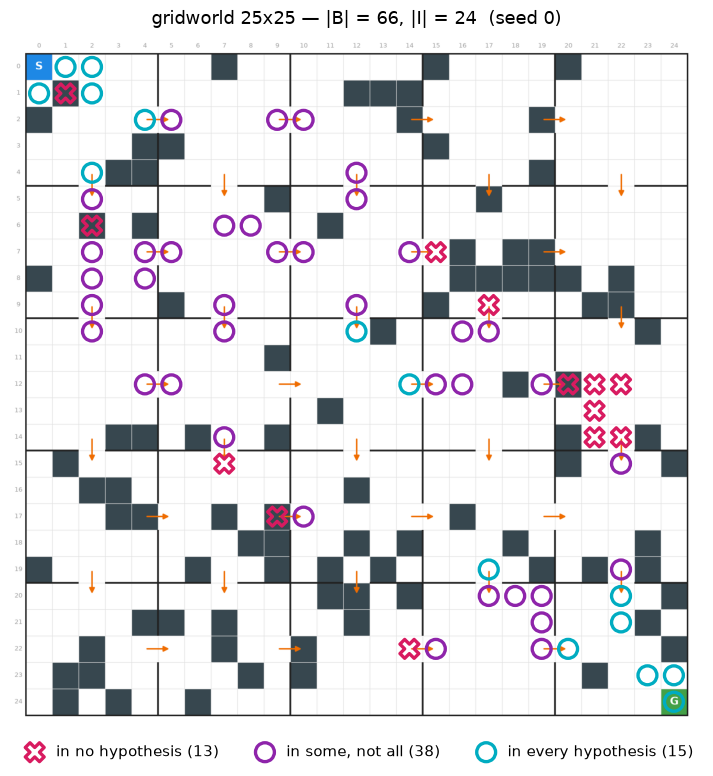

In [15]:
# state[0] is the (row, col) cell in every grid world, and the determinizer indexes
# states in get_state_space() order, so raw bottleneck IDs address this list directly.
positions = {i: tuple(s[0]) for i, s in enumerate(mdp.get_state_space())}

in_none = ~I_array.any(0)
in_all  =  I_array.all(0)
TIERS = [(in_none,                "#d81b60", "X", "in no hypothesis"),
         (~in_none & ~in_all,     "#8e24aa", "o", "in some, not all"),
         (in_all,                 "#00acc1", "o", "in every hypothesis")]

n, pad = mdp.board_side, 0.6              # pad matches render(show_coords=True)
fig, ax = plt.subplots(figsize=(9, 9))
ax.imshow(mdp.render(cell_px=54, show_coords=True),
          extent=(-pad, n + pad, n + pad, -pad))
ax.set_xlim(-pad, n + pad)
ax.set_ylim(n + pad, -pad)
ax.axis("off")

area = (9 * 72.0 / (n + 2 * pad) * 0.55) ** 2      # marker area in points^2
for mask, colour, marker, label in TIERS:
    pts = [positions[b] for b, keep in zip(B, mask) if keep]
    if not pts:
        continue
    rows, cols = zip(*pts)
    ax.scatter([c + 0.5 for c in cols], [r + 0.5 for r in rows],
               s=area, marker=marker, linewidths=2.4, zorder=3,
               edgecolors=colour, facecolors="none",
               label=f"{label} ({len(pts)})")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=3, frameon=False,
          fontsize=11, handletextpad=0.4)
ax.set_title(f"gridworld {n}x{n} — |B| = {len(B)}, |I| = {len(I)}  (seed {SEED})",
             fontsize=13, pad=10)
plt.show()


In [16]:
# Hyperparameter search at |B| = 66 on this instance.  The number to beat is the BOUND-ONLY
# control -- n_rollouts=0, empty envelope, every state falling back to the admissible bound --
# which scores 27.92 (optimistic) / 28.33 (pessimistic) in 0.2 s.  H3 scores 26.92 in 0.01 s.
#
# 1_000 rollouts, one seed, varying each axis:
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 10    75 s   27.83
#   eps 1.00/0.05 frac 0.80  top_k  1_000  beam 10    85 s   28.33   too much exploring
#   eps 0.10/0.02 frac 0.20  top_k  1_000  beam 10    75 s   29.42   too little
#   eps 0.30/0.05 frac 0.20  top_k 10_000  beam 10    86 s   30.67   4x envelope, worse
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 25   172 s   28.92   wider backups, worse
#   eps 0.30/0.05 frac 0.20  top_k  1_000  beam 44   305 s   28.75   (44 restores the 6.7%
#                                                                    keep ratio n=15 had)
# Rollouts swept 0..6_400 (results/rollout_sweep.csv): non-monotonic, e.g. the pessimistic
# fallback gives 24.08 at 1_600 and 29.75 at 3_200.
#
# THE SEED SWEEP IS THE RESULT (results/seed_sweep.csv).  Same config, six PRI_SEEDs:
#   optimistic   mean 28.90  std 0.60  range 28.25-30.08   -> reliably WORSE than 27.92
#   pessimistic  mean 27.14  std 1.54  range 24.08-28.83   -> 1.2 sigma from 27.92, not a win
# So the per-axis differences above are noise, and prioritized sweeping does not beat its own
# admissible bound here.  Read the bars below with that in mind: PRI_SEED = 0 happens to be
# the lucky draw (pessimistic 24.08, the low end of the range), so its bar overstates the
# method.  The mechanism is in the envelope-shape plot -- every layer pinned at the per-layer
# prune budget while covering ~1e-27 of itself, so the backups are a vanishing random sample,
# and replacing a CONSISTENT admissible bound with scattered half-converged values misleads
# the argmax.  That is also why adding capacity (top_k) or width (beam) makes it worse.
N_ROLLOUTS            = 1_600   # ~2 min; the apparent optimum, shown by the seed sweep to be
                                # indistinguishable from any other value
TOP_K                 = 1_000   # NOT raised -- 10_000 measured worse
BACKWARD_TOP_K        = 10      # NOT raised -- 25 and 44 both measured worse
ENVS_PER_WORKER       = 1
ENVELOPE_UPDATE_EVERY = 10
EPS_START, EPS_END, EPS_DECAY_FRAC = 0.30, 0.05, 0.20
METRICS_EVERY         = 3       # 160 batches here -> ~50 points on the convergence panel
PRI_SEED              = 0


In [17]:
import hashlib
import torch
from pri_numba import PriQNet

oracle     = Oracle(oracle_sets, n_states=max(int(T_R.shape[0]), int(goal_state) + 1))
human_sets = oracle.bottleneck_matrix(B)          # (n_humans, |B|) bool
b_to_int   = bottleneck_index(B)

def pri(n_rollouts, **kw):
    return train_pri(PriConfig(
        I_array=I_array, n_bottleneck=len(B), len_I_array=I_array.shape[0],
        c_q=-10.0, p_i=1.0, p_f=0.0, gamma=0.99,
        # episodic_forward answers from one real human per episode, so training and
        # evaluation sit in the same regime.
        episodic_forward=True, forward_bottleneck_sets=human_sets,
        backward_oracle_probs=oracle.probs_for_raw_ids(B),
        eval_bottleneck_sets=human_sets,
        top_k=TOP_K, n_rollouts=n_rollouts,
        # Width of the backward frontier per layer.  It does NOT scale with |B| by
        # default (10 always), so the climb keeps 10 of beam*n candidates -- 6.7% at
        # |B|=15 but 1.5% at |B|=66.  This is the axis that adds Bellman work at fixed
        # capacity, unlike top_k which only adds thin coverage.
        backward_top_k_per_layer=BACKWARD_TOP_K,
        envs_per_worker=ENVS_PER_WORKER, envelope_update_every=ENVELOPE_UPDATE_EVERY,
        eps_start=EPS_START, eps_end=EPS_END, eps_decay_frac=EPS_DECAY_FRAC,
        seed=PRI_SEED, **kw))

RECOMPUTE_PRI = False
# The cache key covers everything that changes the result -- instance and schedule alike.
# Without it a changed parameter would silently load a stale checkpoint.
CACHE_KEY = hashlib.md5(repr((
    ROOMS_PER_SIDE, ROOM_SIDE, OBSTACLE_DENSITY, SLIP_PROB, NUM_HUMANS,
    MIN_HYPOTHESES, SEED, len(B), len(I), N_ROLLOUTS, TOP_K, ENVS_PER_WORKER,
    ENVELOPE_UPDATE_EVERY, EPS_START, EPS_END, EPS_DECAY_FRAC, BACKWARD_TOP_K, PRI_SEED,
)).encode()).hexdigest()[:12]
os.makedirs("pri_cache", exist_ok=True)
CACHE = os.path.join("pri_cache", f"pri_B{len(B)}_r{N_ROLLOUTS}_{CACHE_KEY}.pt")

def pessimistic_of(policy):
    """The pessimistic twin, sharing `policy`'s envelope by reference -- neither writes.

    Only the optimistic policy is checkpointed: PriQNet.__getstate__ flattens the whole
    envelope into the pickle, so saving both would store it twice (~70 MB rather than
    ~35 MB at |B| = 66).  Rebuilding here costs nothing and shares the one copy.
    """
    return PriQNet(n=policy.n, envelope=policy.envelope, I_array_w=policy.I_array_w,
                   full_words=policy.full_words,
                   backward_oracle_probs=policy.backward_oracle_probs,
                   c_q=policy.c_q, p_i=policy.p_i, p_f=policy.p_f, gamma=policy.gamma,
                   bound_kind=1)

if RECOMPUTE_PRI or not os.path.exists(CACHE):
    trained = pri(N_ROLLOUTS, metrics_every=METRICS_EVERY)
    torch.save({k: trained[k] for k in
                ("q_optimistic", "query_counts", "history",
                 "human_query_counts_optimistic", "human_query_counts_pessimistic")}, CACHE)
    print(f"trained and saved -> {CACHE} ({os.path.getsize(CACHE) / 1e6:.1f} MB)")
else:
    trained = torch.load(CACHE, weights_only=False)
    print(f"loaded <- {CACHE} ({os.path.getsize(CACHE) / 1e6:.1f} MB)")

# Two policies over the SAME envelope, differing only in the fallback used for states
# never backed up: optimistic (the admissible bound) vs pessimistic.
pri_optimistic  = trained["q_optimistic"]
pri_pessimistic = pessimistic_of(pri_optimistic)
# Zero rollouts leaves the envelope empty, so every lookup misses and every state falls
# back to the bound: it isolates how much is learned backup and how much is the bound alone.
# Instant to build, so it is never cached.
bound_only = pri(0, metrics_every=10**9, n_workers=1)["q_optimistic"]

print(f"trained envelope {pri_optimistic.envelope.size:,} states, "
      f"bound-only {bound_only.envelope.size}")


loaded <- pri_cache/pri_B66_r1600_9bea9e913c04.pt (35.5 MB)


0it [00:00, ?it/s]

trained envelope 561,937 states, bound-only 0


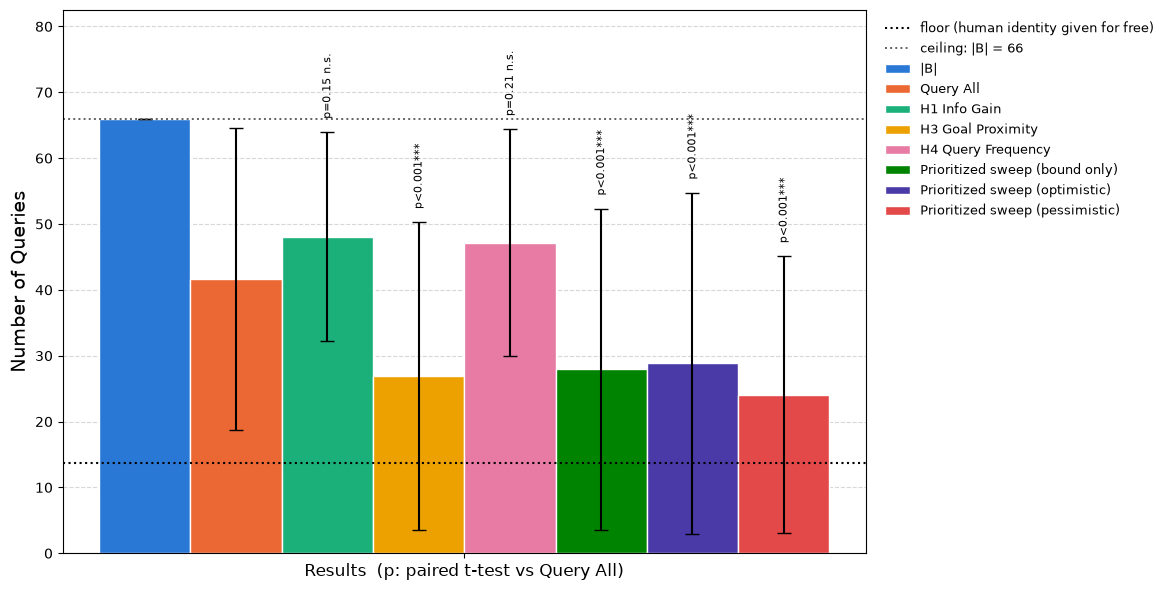

  |B|                                 66.00
  Query All                           41.61
  H1 Info Gain                        48.08
  H3 Goal Proximity                   26.92
  H4 Query Frequency                  47.17
  Prioritized sweep (bound only)      27.92
  Prioritized sweep (optimistic)      28.83
  Prioritized sweep (pessimistic)     24.08
  floor                               13.67

  -> results/summary.csv

  NOTE: the two sweep bars are ONE seed.  Over six PRI_SEEDs at this config the
  optimistic fallback is 28.90 +/- 0.60 and the pessimistic 27.14 +/- 1.54, so neither
  separates from bound-only (27.92) and both lose to H3 (26.92).  See cell above and
  results/seed_sweep.csv.


In [18]:
from itertools import combinations
from scipy import stats

def floor_queries(bits):
    r"""Fewest queries ANY policy could need against a human owning `bits`.

    Representable (S_i inside some I_k): absorption needs I_hat = B \ K_not inside an
    I_k, and only truthful NOs shrink I_hat, so the cost is |B \ I_k| for the roomiest
    I_k containing S_i.  Failure can never fire, since K_I is inside S_i is inside I_k.
    Not representable: success can never fire, so the floor is the fewest YESes that fit
    in no hypothesis at all.
    """
    covering = [k for k in range(len(I_array)) if (I_array[k] | ~bits).all()]
    if covering:
        return min(int((~I_array[k]).sum()) for k in covering)
    owned = np.flatnonzero(bits)
    for size in range(1, len(owned) + 1):
        for Y in combinations(owned, size):
            m = np.zeros(len(B), bool); m[list(Y)] = True
            if not any((I_array[k] | ~m).all() for k in range(len(I_array))):
                return size
    return int(bits.sum())

def queries(policy, runs=1):
    """One number per candidate human -- the mean over `runs` episodes against that human.

    One entry per human, never per episode, because the same humans face every policy: the
    design is PAIRED, and the comparison below is on per-human differences.  Flattening the
    50 Query-All runs into 600 rows would break that pairing and throw away the only thing
    that makes 12 humans enough to separate anything.
    """
    return np.array([evaluate_policy_on_real_human(
        true_bottlenecks=list(s), policy_network=policy, n_runs=runs,
        I_array=I_array, b_to_int=b_to_int)["n_queries"].mean() for s in oracle_sets])

# The three heuristics experiment.py reports.  Same (batch, 2n) -> (batch, n) contract as
# the sweep, so `queries` needs no special case; H3 reads `positions` from the map cell.
h1 = solve_query_mdp_info_gain(I, B, oracle=oracle)
h3 = solve_query_mdp_proximity(I, B, oracle=oracle, positions=positions,
                               goal_state=int(goal_state))
h4 = solve_query_mdp_frequency(I, B, oracle=oracle)

floor = float(np.mean([floor_queries(np.array([b in s for b in B]))
                       for s in oracle_sets]))

SERIES = [("|B|",                             np.full(len(oracle_sets), len(B)), "#2a78d6"),
          ("Query All",                       queries(None, runs=50),            "#eb6834"),
          ("H1 Info Gain",                    queries(h1),                       "#1baf7a"),
          ("H3 Goal Proximity",               queries(h3),                       "#eda100"),
          ("H4 Query Frequency",              queries(h4),                       "#e87ba4"),
          ("Prioritized sweep (bound only)",  queries(bound_only),               "#008300"),
          ("Prioritized sweep (optimistic)",  queries(pri_optimistic),           "#4a3aa7"),
          ("Prioritized sweep (pessimistic)", queries(pri_pessimistic),          "#e34948")]

means = [s.mean() for _, s, _ in SERIES]
stds  = [s.std()  for _, s, _ in SERIES]
k     = len(SERIES)
width = min(0.6 / k, 0.25)
offs  = np.linspace(-(k - 1) * width / 2, (k - 1) * width / 2, k)

fig, ax = plt.subplots(figsize=(3 + 1.1 * k, 6))
for i, (label, _, colour) in enumerate(SERIES):
    ax.bar(offs[i], means[i], width, yerr=stds[i], label=label,
           color=colour, edgecolor="white", capsize=5)
ax.axhline(floor, color="black", ls=":", lw=1.5,
           label="floor (human identity given for free)")
ax.axhline(len(B), color="#616161", ls=":", lw=1.4,
           label=f"ceiling: |B| = {len(B)}")

# Paired t-test against Query All, on per-human differences.  ttest_rel, NOT ttest_ind:
# the humans are shared across policies and bimodal (the non-representable ones terminate in
# ~1-9 queries, the rest in ~50), so the between-human spread dwarfs the between-policy one.
# Unpaired here reports p=0.13 where paired reports p=0.00004 for the same comparison.
BASELINE = 1                                # index of "Query All" in SERIES
top = max(max(m + s for m, s in zip(means, stds)), floor)
for i in range(len(SERIES)):
    if i in (0, BASELINE):                  # |B| is a constant; the baseline vs itself
        continue
    pv = stats.ttest_rel(SERIES[i][1], SERIES[BASELINE][1]).pvalue
    txt = ("p<0.001***" if pv < 0.001 else f"p={pv:.3f}*" if pv < 0.05 else f"p={pv:.2f} n.s.")
    ax.text(offs[i], means[i] + stds[i] + top * 0.03, txt,
            ha="center", va="bottom", fontsize=8, rotation=90)

ax.set_ylabel("Number of Queries", fontsize=14)
ax.set_xticks([0]); ax.set_xticklabels(["Results  (p: paired t-test vs Query All)"], fontsize=12)
ax.set_ylim(0, top * 1.25)
# Outside the axes: with eight bars, their error bars and the rotated p-values, an inside
# legend covers the data it describes.
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
ax.grid(axis="y", ls="--", alpha=0.5); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

import csv
with open(os.path.join(RESULTS_DIR, "summary.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["board", mdp.board_side, "|B|", len(B), "|I|", len(I),
                "humans", len(oracle_sets), "n_rollouts", N_ROLLOUTS,
                "top_k", TOP_K, "beam", BACKWARD_TOP_K])
    w.writerow(["policy", "mean_queries", "std"])
    for (label, s, _), m, sd in zip(SERIES, means, stds):
        w.writerow([label, round(float(m), 3), round(float(sd), 3)])
    w.writerow(["floor", round(floor, 3), 0])

for (label, s, _), m in zip(SERIES, means):
    print(f"  {label:34s} {m:6.2f}")
print(f"  {'floor':34s} {floor:6.2f}")
print(f"\n  -> {os.path.join(RESULTS_DIR, 'summary.csv')}")
print("\n  NOTE: the two sweep bars are ONE seed.  Over six PRI_SEEDs at this config the\n"
      "  optimistic fallback is 28.90 +/- 0.60 and the pessimistic 27.14 +/- 1.54, so neither\n"
      "  separates from bound-only (27.92) and both lose to H3 (26.92).  See cell above and\n"
      "  results/seed_sweep.csv.")


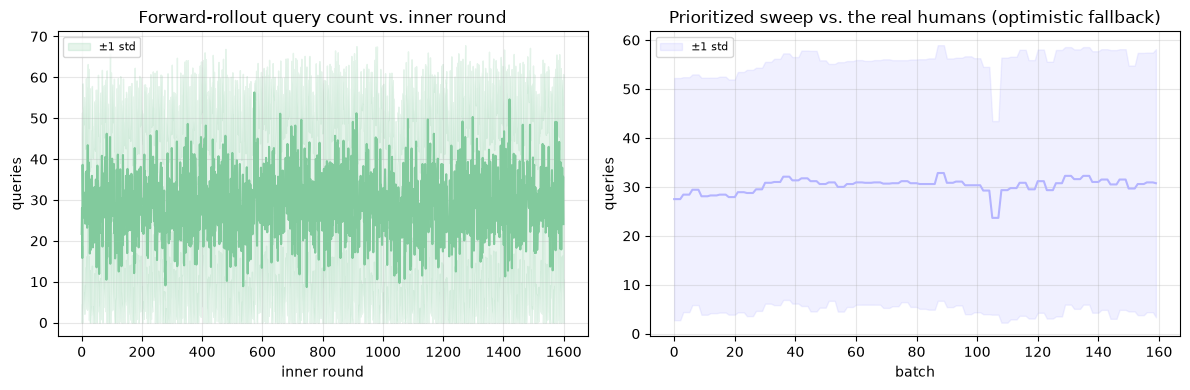

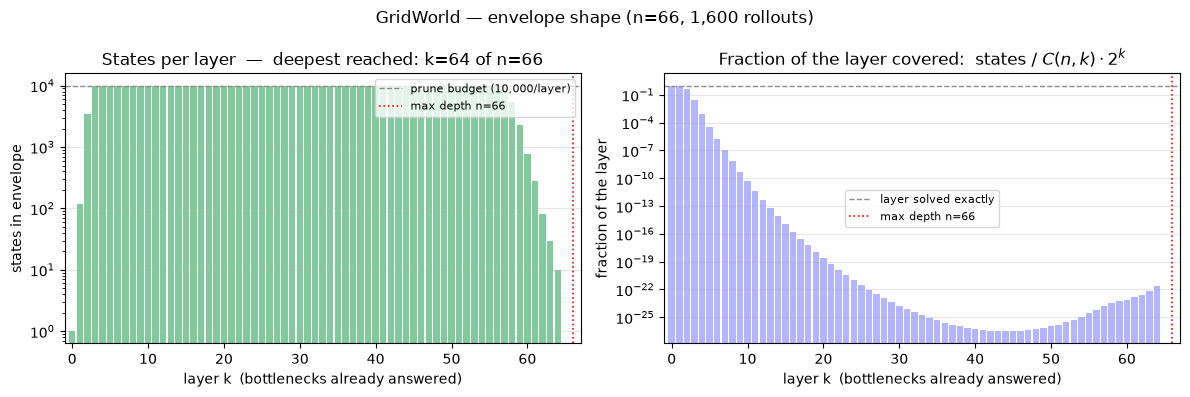

In [19]:
# Only the two plot helpers, never viz's own evaluate_policy_on_real_human: it is an
# older duplicate of the one bottlenecks.py exports.
from viz import plot_query_convergence, plot_envelope_shape

plot_query_convergence(
    trained["query_counts"], trained["human_query_counts_optimistic"],
    human_title="Prioritized sweep vs. the real humans (optimistic fallback)")

# keep = TOP_K * keep_margin, and keep_margin defaults to 10.0 -- the per-layer prune
# budget, so a flat top means the layer is capacity-limited rather than unreached.
plot_envelope_shape(
    pri_optimistic.envelope, keep=TOP_K * 10,
    title=f"GridWorld — envelope shape (n={len(B)}, {N_ROLLOUTS:,} rollouts)")


---
# Study log — rail-guarded NN approximation

**Aim of `big_Q_games/`:** compare query-selection policies where exact VI is unaffordable.
This instance has |B| = 66, so VI would need 3^66 ~ 10^31 knowledge states.

**This log**, 2026-08-21: a DQN with *provable guardrails*. Where the optimal policy's
behaviour is known analytically, we enforce it rather than hoping the network learns it.

Everything below is self-contained — it imports from `dqn.py` / `rails.py` / `benchmark.py`
and rebuilds the instance in a few seconds. It does **not** depend on the PRI cells above.

**Cost of re-running.** Cells §1-§14 are seconds. Four cells wrap studies that are
expensive to recompute and therefore **read cached results from `results/` by default**:

| cell | study | cost if recomputed |
|---|---|---|
| §4 | `benchmark.py` | ~1 min |
| §8 | `multi_instance.py` (20 maps) | ~4 min, CPU |
| §15 | `multi_dqn.py` (8 training runs) | **~95 min, ~1 GB GPU** |
| §16 | `loo_check.py` (4 training runs) | **~40 min** |

Pass `rerun=True` to recompute one. The whole notebook otherwise executes in ~16 s.


## 1. The two rails

Given the knowledge state, the **compatible** hypotheses are `C = {k : K_I ⊆ I_k}`.
Only compatible `k` matter, because success needs `I_hat ⊆ I_k` and `K_I ⊆ I_hat`, so any
witness to success is compatible already.

Every unqueried bottleneck then falls into one of three tiers:

| tier | condition | rail | why it is *provably* right |
|---|---|---|---|
| **1** | in **no** `I_k`, k ∈ C | **ask first** | YES ⇒ `K_I` fits no hypothesis ⇒ failure fires, episode over. NO ⇒ removes a blocker from `I_hat` for **every** hypothesis at once. |
| 2 | in some but not all | the network decides | — |
| **3** | in **every** `I_k`, k ∈ C | **never ask** | YES leaves `C` unchanged, cannot cause failure. NO removes `b` from `I_hat`, but `b ∈ I_k` was never why `I_hat ⊄ I_k`. **Neither answer can move `(done, success)`.** |

The tiers are recomputed from the live knowledge state: as YES answers shrink `C`,
bottlenecks migrate between tiers. A bottleneck that is in *some* hypothesis today can be
in *every remaining* one tomorrow, at which point it must stop being asked.


In [20]:
import sys, os
ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "big_Q_games" else os.getcwd()
sys.path.insert(0, ROOT); sys.path.insert(0, os.path.join(ROOT, "big_Q_games"))
import numpy as np
from rails import tiers, compatible

# Hand-built instance small enough to verify by eye.
#   bottlenecks 0..3;  I_0 = {0,1}   I_1 = {0,2}   I_2 = {1,2,3}
I_toy = np.array([[1,1,0,0],
                  [1,0,1,0],
                  [0,1,1,1]], dtype=bool)

K_I, K_not = np.zeros(4, bool), np.zeros(4, bool)
t1, t3 = tiers(K_I, K_not, I_toy)
print(f"empty state      compatible={np.flatnonzero(compatible(K_I, I_toy))}"
      f"  tier1={np.flatnonzero(t1)}  tier3={np.flatnonzero(t3)}")

# A YES on b3 kills I_0 and I_1 (neither contains 3), leaving only I_2 = {1,2,3}.
# So b0 is now in NO compatible hypothesis (tier 1), and b1,b2 are in EVERY one (tier 3).
K_I = np.array([0,0,0,1], bool)
t1, t3 = tiers(K_I, K_not, I_toy)
print(f"after YES on b3  compatible={np.flatnonzero(compatible(K_I, I_toy))}"
      f"  tier1={np.flatnonzero(t1)}  tier3={np.flatnonzero(t3)}")
print("\n-> the mask adapts as hypotheses die: b1,b2 became un-askable, b0 became urgent")


import subprocess
RES = os.path.join(ROOT, "big_Q_games", "results")

def run_or_cache(script, args, outfile, minutes, rerun=False):
    """Run a study script only when its output is missing, or rerun is asked for.

    The expensive cells retrain from scratch: multi_dqn is ~95 min and holds ~1 GB of
    GPU memory, loo_check ~40 min.  Their results are on disk, so re-executing the
    notebook should read them rather than recompute them.
    """
    path = os.path.join(RES, outfile)
    if not rerun and os.path.exists(path):
        print(f"using cached {outfile}  (set rerun=True to recompute, ~{minutes} min)")
        return
    cmd = [os.path.join(ROOT, ".venv", "bin", "python"),
           os.path.join(ROOT, "big_Q_games", script)] + [str(a) for a in args]
    print(f"running {script} (~{minutes} min) ...")
    print(subprocess.run(cmd, capture_output=True, text=True).stdout)


empty state      compatible=[0 1 2]  tier1=[]  tier3=[]
after YES on b3  compatible=[2]  tier1=[0]  tier3=[1 2]

-> the mask adapts as hypotheses die: b1,b2 became un-askable, b0 became urgent


### 1.1 Exhaustive verification

The claims above are checked against `bottlenecks._terminal` itself — not against a
reimplementation of it — on **every** knowledge state of small instances (3^n states,
n = 4..7). For each state and each tier claim:

* tier 1 → a YES **must** produce `(done=True, success=False)`
* tier 3 → a YES **and** a NO must both leave `(done, success)` exactly as they were,
  and a YES must leave the compatible set identical
* neither tier may ever name an already-answered bottleneck, and the two must be disjoint


In [21]:
!"{ROOT}/.venv/bin/python" "{ROOT}/big_Q_games/test_rails.py"


1. hand-built instance, checked by hand
  empty state       tier1=[]  tier3=[]
  after YES on b3   compatible=[2]  tier1=[0]  tier3=[1 2]
  -> tiers migrate as the compatible set shrinks: confirmed

2. exhaustive over every knowledge state, random instances
  5,662 non-terminal states checked
  5,839 tier-1 claims verified (YES must fail-terminate)
  3,713 tier-3 claims verified (neither answer may move termination)

ALL TESTS PASSED

3. absorbing tiers, and tier-1 mandatory
  4,187 non-terminal states
  tier-1 membership lost after a query : 0
  tier-3 membership lost after a query : 0
  success reached with a tier-1 bit unasked : 0

  CONFIRMED: both tiers absorbing, tier-1 mandatory


## 2. Does the *deployed* policy obey the rails?

Proving the tier logic is not the same as proving the pipeline uses it. `RailedQNet`
adds a finite bias to the network's output — `+1e6` for tier 1, `−1e6` for tier 3 —
and stays a drop-in for `evaluate_policy_on_real_human`, which builds
`obs = [K_I ‖ K_not]`, masks answered bits at `−1e9`, and argmaxes.

The biases are **finite on purpose**. If tier 3 were `−1e9` too, a state where every
live action is tier 3 would tie with the answered bits and the argmax could return an
already-answered bottleneck, looping the episode. (That state is provably unreachable —
if every unqueried bottleneck were in every compatible hypothesis then `I_hat ⊆ I_k`
and success would already have fired — but the code should not depend on that.)

The audit below replays real episodes against the 12 real humans, recomputing the tiers
at every decision and checking the action actually taken.


In [22]:
!"{ROOT}/.venv/bin/python" "{ROOT}/big_Q_games/audit_rails.py"


12 episodes, 303 decisions, mean length 25.25

RAIL VIOLATIONS
  chose an already-answered bottleneck : 0
  chose a tier-3 (provably useless)    : 0
  tier-1 available but not chosen      : 0

HOW OFTEN THE RAILS CAN BITE (untrained net, so this is the instance's own shape)
  decisions with >=1 tier-1 available  : 138/303 (46%)
  decisions with >=1 tier-3 available  : 303/303 (100%)

AUDIT PASSED


### 2.1 Reading the audit

Two facts, and the second is the interesting one:

* **Zero violations** — no tier-3 query, no missed tier-1, no illegal action.
* **A tier-3 mask exists at 100% of decisions, tier-1 at 46%.** The rails are not a
  rare edge case on this instance; they bite at every single step.

The audit runs an **untrained** network, so its query count is what the guardrails alone
achieve with random tier-2 choices. That number turns out to matter — see §3.


## 3. What are the rails worth *without any learning*?

`RailsOnlyNet` is the guardrails with no network at all: tier 1 first, tier 3 never,
uniformly random among tier 2. It is the correct control for "how much of any railed
result is the rails rather than the DQN", and it costs no training.


In [23]:
import numpy as np
from scipy import stats
from dqn import build_instance, per_human
from rails import RailsOnlyNet
from bottlenecks import (solve_query_mdp_info_gain, solve_query_mdp_proximity,
                         solve_query_mdp_frequency)

ins = build_instance(0)
I_array = ins["I_array"]

# 20 random tier-2 orderings; per-human means, so the comparison stays paired
rails_v = np.mean([per_human(RailsOnlyNet(I_array, seed=s), ins) for s in range(20)], axis=0)
h1 = per_human(solve_query_mdp_info_gain(ins["I"], ins["B"], oracle=ins["oracle"]), ins)
h3 = per_human(solve_query_mdp_proximity(ins["I"], ins["B"], oracle=ins["oracle"],
                                         positions=ins["positions"], goal_state=ins["goal"]), ins)
h4 = per_human(solve_query_mdp_frequency(ins["I"], ins["B"], oracle=ins["oracle"]), ins)

print(f"{'policy':<22} {'mean':>7}   paired t-test vs rails-only")
print(f"{'Rails only (no NN)':<22} {rails_v.mean():>7.2f}")
for name, v in (("H1 Info Gain", h1), ("H3 Goal Proximity", h3), ("H4 Query Frequency", h4)):
    p = stats.ttest_rel(rails_v, v).pvalue
    print(f"{name:<22} {v.mean():>7.2f}   diff {rails_v.mean()-v.mean():+6.2f}   p = {p:.4f}")
print(f"\nper-human, rails-only : {rails_v.round(1)}")
print(f"per-human, H3         : {h3.astype(int)}")


policy                    mean   paired t-test vs rails-only
Rails only (no NN)       23.77
H1 Info Gain             48.08   diff -24.31   p = 0.0000
H3 Goal Proximity        26.92   diff  -3.15   p = 0.0630
H4 Query Frequency       47.17   diff -23.40   p = 0.0001

per-human, rails-only : [ 2.7 48.2 37.9 45.4 45.6  4.2  5.8  2.8 41.2 41.6  7.   3. ]
per-human, H3         : [ 2 50 50 50 50  8  9  1 50 51  1  1]


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**Rails alone already beat two of the three heuristics**

The guardrails with **zero training** score **23.77 ± 0.76** (20 random orderings).

* vs **H1** (48.08): −24.3, p < 0.0001
* vs **H4** (47.17): −23.4, p = 0.0001
* vs **H3** (26.92): −3.15, p = 0.063 — better, but not resolvable with 12 humans

So most of what a railed network achieves is not learned at all: it is the two provable
constraints. Any railed DQN result must be read against **23.77**, not against H3.

The per-human vectors show *where* it wins. H3 is bimodal — it disposes of the six
non-representable humans in 1–9 queries and then needs ~50 for the rest. Rails-only is
comparable on the easy ones and clearly better on the hard ones (38–48 vs 50–51),
because a tier-3 mask is available at every decision and keeps it from wasting queries
on bottlenecks that cannot change the outcome.

</div>


## 4. The full benchmark

`benchmark.py` assembles one **per-human** query count for every policy and writes
`results/benchmark_per_human.csv`. Classical policies are recomputed in seconds; DQN rows
are read from the `dqn_humans_*.csv` files that `dqn.py` appends as each run finishes,
averaged over whatever seeds are present.

Re-run the cell below to pick up runs that finished after the last execution.


In [24]:
# ~1 min if recomputed.  Cached output is read by default.
run_or_cache("benchmark.py", [], "benchmark_per_human.csv", 1, rerun=False)


using cached benchmark_per_human.csv  (set rerun=True to recompute, ~1 min)


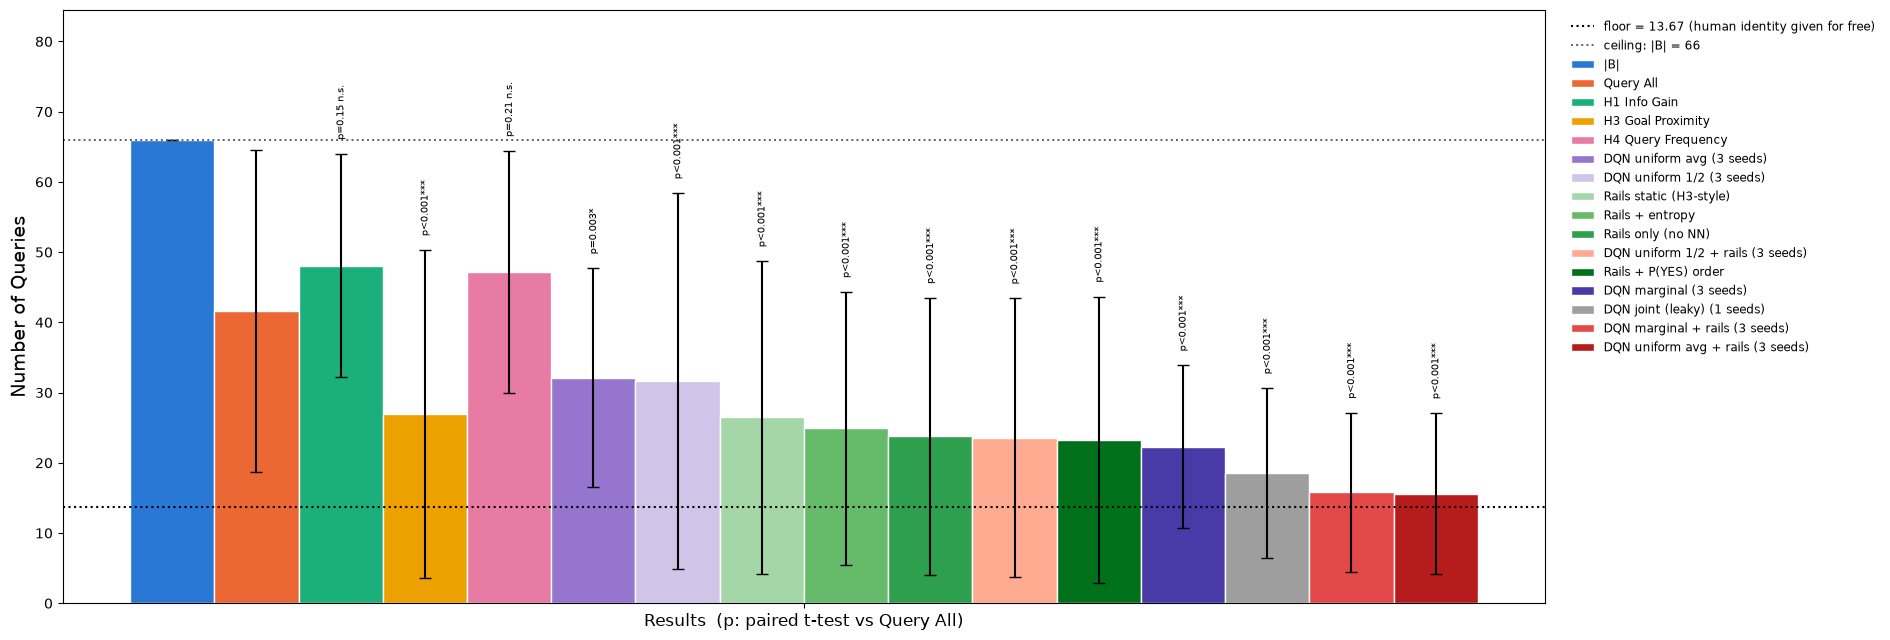

policy                          mean     std    vs H3    p vs H3
Query All                      41.61   22.93   +14.69     0.0000
H1 Info Gain                   48.08   15.91   +21.17     0.0007
H3 Goal Proximity              26.92   23.38    +0.00        nan
H4 Query Frequency             47.17   17.24   +20.25     0.0010
DQN uniform avg                32.11   15.59    +5.19     0.1307
DQN uniform 1/2                31.61   26.78    +4.69     0.0119
Rails static (H3-style)        26.47   22.25    -0.45     0.6011
Rails + entropy                24.92   19.41    -2.00     0.2772
Rails only (no NN)             23.77   19.71    -3.15     0.0630
DQN uniform 1/2 + rails        23.56   19.87    -3.36     0.0245
Rails + P(YES) order           23.30   20.37    -3.62     0.0146
DQN marginal                   22.28   11.60    -4.64     0.2998
DQN joint (leaky)              18.50   12.12    -8.42     0.0449
DQN marginal + rails           15.78   11.35   -11.14     0.0141
DQN uniform avg + rails  

In [25]:
import csv, collections
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
%matplotlib inline

RES = os.path.join(ROOT, "big_Q_games", "results")
rows = list(csv.DictReader(open(os.path.join(RES, "benchmark_per_human.csv"))))
vals, seeds = collections.defaultdict(list), {}
for r in rows:
    vals[r["policy"]].append(float(r["n_queries"]))
    seeds[r["policy"]] = r["n_seeds"]
vals = {k: np.array(v) for k, v in vals.items()}

floor = vals["floor"].mean()
nB = int(vals["|B|"][0])

# Order: the reference columns first, then everything else by how well it does, so the
# figure reads left-to-right as "worse -> better" among the policies being compared.
# Families are colour-coded: blue/orange references, warm heuristics, GREEN for the
# training-free rails ladder, PURPLE for unrailed DQN, RED for railed DQN.
COLOUR = {"|B|": "#2a78d6", "Query All": "#eb6834",
          "H1 Info Gain": "#1baf7a", "H3 Goal Proximity": "#eda100",
          "H4 Query Frequency": "#e87ba4",
          "Rails static (H3-style)": "#a5d6a7", "Rails + entropy": "#66bb6a",
          "Rails only (no NN)": "#2e9e4f", "Rails + P(YES) order": "#00701a",
          "DQN uniform 1/2": "#d1c4e9", "DQN uniform avg": "#9575cd",
          "DQN marginal": "#4a3aa7", "DQN joint (leaky)": "#9e9e9e",
          "DQN uniform 1/2 + rails": "#ffab91", "DQN marginal + rails": "#e34948",
          "DQN uniform avg + rails": "#b71c1c"}
HEAD = ["|B|", "Query All", "H1 Info Gain", "H3 Goal Proximity", "H4 Query Frequency"]
rest = sorted([k for k in vals if k not in HEAD + ["floor"]],
              key=lambda k: -vals[k].mean())
SERIES = [(k, vals[k], COLOUR.get(k, "#777777")) for k in HEAD + rest]

means = [s.mean() for _, s, _ in SERIES]
stds  = [s.std()  for _, s, _ in SERIES]
k     = len(SERIES)
width = min(0.6 / k, 0.25)
offs  = np.linspace(-(k - 1) * width / 2, (k - 1) * width / 2, k)

fig, ax = plt.subplots(figsize=(3 + 1.0 * k, 6.5))
for i, (label, _, colour) in enumerate(SERIES):
    tag = f" ({seeds[label]} seeds)" if seeds.get(label) else ""
    ax.bar(offs[i], means[i], width, yerr=stds[i], label=label + tag,
           color=colour, edgecolor="white", capsize=4)
ax.axhline(floor, color="black", ls=":", lw=1.5,
           label=f"floor = {floor:.2f} (human identity given for free)")
ax.axhline(nB, color="#616161", ls=":", lw=1.4, label=f"ceiling: |B| = {nB}")

# Paired t-test against Query All: the same 12 humans face every policy, and they are
# bimodal (non-representable ones absorb in ~1-9 queries, the rest need ~50), so the
# between-human spread dwarfs the between-policy one.  Unpaired would hide everything.
BASELINE = 1
top = max(max(m + s for m, s in zip(means, stds)), floor)
for i in range(len(SERIES)):
    if i in (0, BASELINE):
        continue
    pv = stats.ttest_rel(SERIES[i][1], SERIES[BASELINE][1]).pvalue
    txt = ("p<0.001***" if pv < 0.001 else f"p={pv:.3f}*" if pv < 0.05 else f"p={pv:.2f} n.s.")
    ax.text(offs[i], means[i] + stds[i] + top * 0.03, txt,
            ha="center", va="bottom", fontsize=7.5, rotation=90)

ax.set_ylabel("Number of Queries", fontsize=14)
ax.set_xticks([0]); ax.set_xticklabels(["Results  (p: paired t-test vs Query All)"], fontsize=12)
ax.set_ylim(0, top * 1.28)
ax.legend(fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1.0), frameon=False)
plt.tight_layout()
plt.savefig(os.path.join(RES, "benchmark_rails.png"), dpi=140, bbox_inches="tight")
plt.show()

print(f"{'policy':<28} {'mean':>7} {'std':>7}  {'vs H3':>7}  {'p vs H3':>9}")
h3v = vals["H3 Goal Proximity"]
for name, v, _ in SERIES:
    if name == "|B|":
        continue
    p = stats.ttest_rel(v, h3v).pvalue if name != "H3 Goal Proximity" else float("nan")
    print(f"{name:<28} {v.mean():>7.2f} {v.std():>7.2f}  {v.mean()-h3v.mean():>+7.2f}  {p:>9.4f}")


## 5. Training curves

`dqn.py` logs the **real metric** — mean queries against the 12 humans, via
`bottlenecks.evaluate_policy_on_real_human` — every 2 000 steps, alongside loss and
`maxQ(s₀)`. So the curve is the thing we care about, not a proxy.

Two things to read here:

* **`maxQ(s₀)` must stay in ≈[−500, +1].** A policy taking 66 queries at `c_q = −10`,
  `γ = 0.99` is worth ≈ −484, so anything outside that band is divergence. An earlier
  configuration (`lr = 1e-3`, `target_sync = 200`, `buffer_cap = 30k`) reached **+3 975**
  by step 50 000 and **−198 847** by 176 000; that is why the current run uses
  `lr = 3e-4`, `target_sync = 1 000`, `buffer_cap = 500 000`.
* **Endpoint vs plateau.** The benchmark table uses the *final* network. When a curve is
  noisy, that endpoint is one draw from a fluctuating policy and can be well below the
  plateau it belongs to. Where the two disagree, the plateau is the honest estimate.


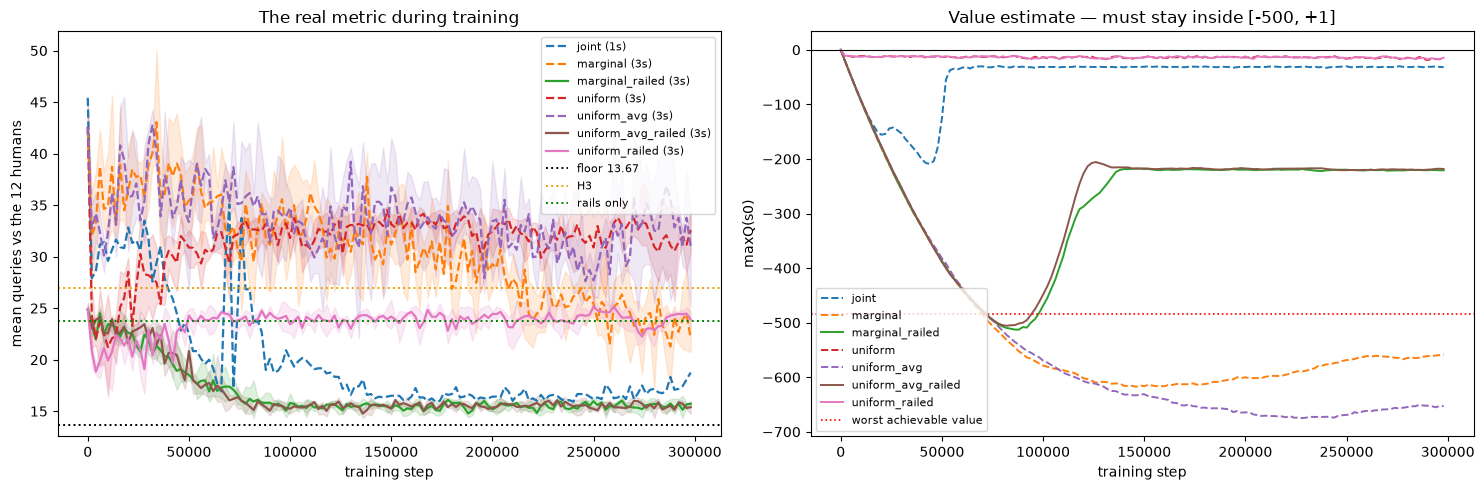

run                        seeds  plateau>100k    std  endpoint
marginal_railed                3         15.51   0.48     15.72
uniform_avg_railed             3         15.53   0.44     15.39
joint                          1         16.99   1.04     18.75
uniform_railed                 3         23.95   0.93     23.92
marginal                       3         28.30   4.51     22.08
uniform                        3         32.45   2.01     32.58
uniform_avg                    3         32.64   4.08     31.00


In [26]:
import glob, csv
import matplotlib.pyplot as plt
import numpy as np

paths = sorted(glob.glob(os.path.join(RES, "dqn_metrics_*.csv")))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
summary = []
for path in paths:
    tag = os.path.basename(path)[len("dqn_metrics_"):-len(".csv")]
    rows = list(csv.DictReader(open(path)))
    if not rows:
        continue
    sds = sorted({int(r["seed"]) for r in rows})
    step = np.array([int(r["step"]) for r in rows if int(r["seed"]) == sds[0]])
    Q = np.array([[float(r["queries"]) for r in rows if int(r["seed"]) == s] for s in sds
                  if sum(1 for r in rows if int(r["seed"]) == s) == len(step)])
    M = np.array([[float(r["maxq0"]) for r in rows if int(r["seed"]) == s] for s in sds
                  if sum(1 for r in rows if int(r["seed"]) == s) == len(step)])
    if not len(Q):
        continue
    ls = "-" if tag.endswith("_railed") else "--"
    l, = axes[0].plot(step, Q.mean(0), ls, lw=1.6, label=f"{tag} ({len(Q)}s)")
    if len(Q) > 1:
        axes[0].fill_between(step, Q.min(0), Q.max(0), color=l.get_color(), alpha=0.15)
    axes[1].plot(step, M.mean(0), ls, lw=1.4, color=l.get_color(), label=tag)
    late = Q[:, step >= 100_000]
    summary.append((tag, len(Q), late.mean(), late.std(), Q[:, -1].mean()))

axes[0].axhline(floor, color="black", ls=":", lw=1.4, label=f"floor {floor:.2f}")
axes[0].axhline(vals["H3 Goal Proximity"].mean(), color="#eda100", ls=":", lw=1.4, label="H3")
axes[0].axhline(vals["Rails only (no NN)"].mean(), color="#008300", ls=":", lw=1.4,
                label="rails only")
axes[0].set_xlabel("training step"); axes[0].set_ylabel("mean queries vs the 12 humans")
axes[0].set_title("The real metric during training"); axes[0].legend(fontsize=8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axhline(-484, color="red", ls=":", lw=1.2, label="worst achievable value")
axes[1].set_xlabel("training step"); axes[1].set_ylabel("maxQ(s0)")
axes[1].set_title("Value estimate — must stay inside [-500, +1]"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RES, "training_curves.png"), dpi=140, bbox_inches="tight")
plt.show()

print(f"{'run':<26} {'seeds':>5} {'plateau>100k':>13} {'std':>6} {'endpoint':>9}")
for t, ns, m, s, e in sorted(summary, key=lambda r: r[2]):
    print(f"{t:<26} {ns:>5} {m:>13.2f} {s:>6.2f} {e:>9.2f}")


## 6. Why H1 is worse than random — and what fixes it

H1 scores **48.08**, worse than querying in a random order (41.61). The tier structure
explains it exactly.

H1 maximises one-step entropy over the compatible hypotheses: it prefers a bottleneck
whose YES-fraction `f` among compatible `I_k` is near ½. But

* a **tier-1** bottleneck has `f = 0` — in no compatible hypothesis
* a **tier-3** bottleneck has `f = 1` — in every one

Both score **zero entropy**, so H1 ranks them last. Avoiding tier 3 is right. Avoiding
tier 1 is a disaster: `f = 0` is exactly the case where a YES ends the episode
immediately, and a NO clears a blocker from every hypothesis at once. H1 does not merely
lack the useful rail — it **inverts** it.

Prediction: bolt the rails onto H1's own entropy rule and it should stop being terrible.


In [27]:
from rails import RailsEntropyNet
re_v = per_human(RailsEntropyNet(I_array), ins)
ro_v = rails_v   # from section 3

print(f"{'policy':<28} {'mean':>7}")
print(f"{'H1 (entropy, no rails)':<28} {h1.mean():>7.2f}")
print(f"{'Rails + entropy':<28} {re_v.mean():>7.2f}")
print(f"{'Rails only (random tier 2)':<28} {ro_v.mean():>7.2f}")
print()
for nm, v in (("H1", h1), ("rails-only", ro_v), ("H3", h3)):
    d = re_v.mean() - v.mean()
    print(f"rails+entropy vs {nm:<12} {d:+6.2f}   p = {stats.ttest_rel(re_v, v).pvalue:.4f}")


policy                          mean
H1 (entropy, no rails)         48.08
Rails + entropy                24.92
Rails only (random tier 2)     23.77

rails+entropy vs H1           -23.17   p = 0.0000
rails+entropy vs rails-only    +1.15   p = 0.1840
rails+entropy vs H3            -2.00   p = 0.2772


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The rails are the whole story; the heuristic on top of them is not**

Adding the two rails to H1's *own* entropy rule moves it **48.08 → 24.92**, p < 0.0001.
A 23-query improvement from two provable constraints, with no new information and no
learning.

But rails + entropy (24.92) is **not** better than rails + a coin flip (23.77) —
p = 0.18, and the sign even favours the coin flip. So on this instance the entire
contribution is the rails; which tier-2 bottleneck you pick next barely matters.

That reframes what the DQN has to beat. The bar is not H3 (26.92), it is
**rails-only, 23.77 ± 0.76** — and the honest question for §7 is whether a trained
network adds anything at all on top of constraints that are free.

</div>


## 7. Where the rails bite

Whether a guardrail can matter is an empirical property of the instance, not of the
method. `tier_stats.py` walks real episodes and records the tier composition at every
decision.


In [28]:
!"{ROOT}/.venv/bin/python" "{ROOT}/big_Q_games/tier_stats.py"


286 decisions across 12 humans

                                      mean  % of live
tier 1  (must ask first)               3.2         7%
tier 2  (policy decides)              26.9        58%
tier 3  (must never ask)              16.4        35%

live actions per decision: 46.5
decisions where tier 1 forced the choice: 134/286 (47%)
decisions with a tier-3 mask available  : 286/286 (100%)

-> the policy genuinely chooses on 53% of decisions; the rest are forced by rail 1

 step   live    t1    t2    t3
    0   66.0  13.0  38.0  15.0
    2   64.0  11.0  38.0  15.0
    5   61.0   8.0  38.0  15.0
   10   56.0   3.0  38.0  15.0
   20   46.0   0.7  28.3  17.0
   30   36.0   0.0  17.5  18.5
   40   26.0   0.0   9.0  17.0


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**A third of every menu is provably useless, and half the decisions are not decisions**

Averaged over 286 real decisions with 46.5 live actions each:

| tier | mean count | share of live actions |
|---|---|---|
| 1 — must ask first | 3.2 | 7% |
| 2 — policy decides | 26.9 | 58% |
| 3 — **must never ask** | 16.4 | **35%** |

**Tier 3 is available at 100% of decisions.** An unrailed policy is choosing from a menu
where roughly a third of the entries cannot change the outcome under either answer. That
is the mechanism behind the 23-query improvement in §6 — nothing subtle, just a policy
being stopped from wasting a third of its options.

**Tier 1 forces 47% of decisions**, so the learned network only genuinely chooses on
about half of them. Any comparison between railed networks is a comparison over that
half.

The within-episode evolution shows both rails are dynamic, in opposite directions:

```
 step   live    t1    t2    t3
    0   66.0  13.0  38.0  15.0
   10   56.0   3.0  38.0  15.0
   20   46.0   0.7  28.3  17.0
   40   26.0   0.0   9.0  17.0
```

Tier 1 is an **opening** phenomenon — 13 bottlenecks at the start, exhausted by step ~20.
Tier 3 *grows* (15 → 18) as YES answers kill hypotheses and more bottlenecks become
common to every survivor. A static mask computed once at step 0 would be wrong by the
midgame in both directions, which is why the tiers are recomputed at every step.

</div>


## 8. Does any of this survive off map seed 0?

Everything above is one hand-picked instance. Seed 0 has **|I| = 24 — the maximum over
40 screened seeds** (median 8, and `min_hypotheses = 6` binds on 30% of draws), so it is
the single most policy-favourable map in the sample. Effect sizes measured there are
almost certainly inflated.

The rails are analytic and need **no training**, so unlike every DQN result the
population question is answerable in minutes. `multi_instance.py` rebuilds 20 instances
and scores every training-free policy on each.

Note the unit of analysis changes: §1-7 pair over **12 humans within one map**;
here we pair over **20 maps**, which is the comparison that supports a claim about the
domain rather than about this board.


In [29]:
# ~4 min if recomputed.  Cached output is read by default.
run_or_cache("multi_instance.py", [20], "multi_instance.csv", 4, rerun=False)


using cached multi_instance.csv  (set rerun=True to recompute, ~4 min)


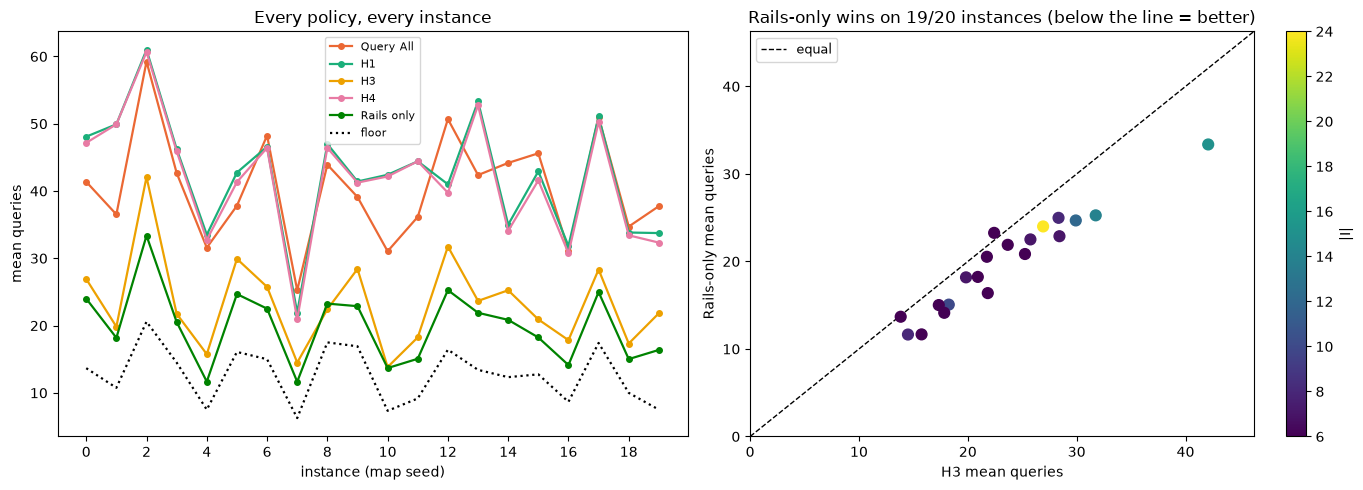

gap to floor closed, mean over 20 instances:
  H1                    -8%
  H3                    62%
  H4                    -6%
  Rails only            74%
  Rails + entropy       73%


In [30]:
import csv
import numpy as np
import matplotlib.pyplot as plt

rows = list(csv.DictReader(open(os.path.join(RES, "multi_instance.csv"))))
seeds = sorted({int(r["seed"]) for r in rows})
def series(pol):
    return np.array([float(r["mean_queries"]) for r in rows if r["policy"] == pol])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for pol, c in (("Query All", "#eb6834"), ("H1", "#1baf7a"), ("H3", "#eda100"),
               ("H4", "#e87ba4"), ("Rails only", "#008300"), ("floor", "black")):
    axes[0].plot(seeds, series(pol), "o-" if pol != "floor" else ":",
                 color=c, lw=1.6, ms=4, label=pol)
axes[0].set_xlabel("instance (map seed)"); axes[0].set_ylabel("mean queries")
axes[0].set_title("Every policy, every instance"); axes[0].legend(fontsize=8)
axes[0].set_xticks(seeds[::2])

h3, ro, fl = series("H3"), series("Rails only"), series("floor")
lim = [0, max(h3.max(), ro.max()) * 1.1]
axes[1].plot(lim, lim, "k--", lw=1, label="equal")
axes[1].scatter(h3, ro, c=[float(r["n_I"]) for r in rows if r["policy"] == "H3"],
                cmap="viridis", s=60, zorder=3)
cb = plt.colorbar(axes[1].collections[0], ax=axes[1]); cb.set_label("|I|")
axes[1].set_xlabel("H3 mean queries"); axes[1].set_ylabel("Rails-only mean queries")
axes[1].set_title(f"Rails-only wins on {(ro < h3).sum()}/{len(seeds)} instances"
                  " (below the line = better)")
axes[1].set_xlim(lim); axes[1].set_ylim(lim); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(RES, "multi_instance.png"), dpi=140, bbox_inches="tight")
plt.show()

print(f"gap to floor closed, mean over {len(seeds)} instances:")
qa = series("Query All")
for pol in ("H1", "H3", "H4", "Rails only", "Rails + entropy"):
    v = series(pol)
    print(f"  {pol:<18} {100*np.mean((qa - v) / (qa - fl)):>5.0f}%")


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The rails generalise; seed 0 was not doing the work**

Across **20 independent maps** (|B| 49-89, |I| 6-24), pairing at the instance level:

| comparison | mean diff | instances won | p |
|---|---|---|---|
| rails-only vs **H1** | −22.49 | **20/20** | < 0.00001 |
| rails-only vs **H4** | −21.80 | **20/20** | < 0.00001 |
| rails-only vs **Query All** | −20.61 | **20/20** | < 0.00001 |
| rails-only vs **H3** | −3.40 | **19/20** | < 0.00001 |

On seed 0 alone, rails-vs-H3 was −3.15 at **p = 0.063** — suggestive, unresolvable with
12 humans. Pairing over 20 maps resolves it decisively at the same effect size. The
effect was always there; 12 humans simply could not see it.

Two further points:

* **Rails + entropy (20.12) still ties rails-only (19.91)** across 20 instances. The
  §6 finding was not a seed-0 artefact: the entropy heuristic contributes nothing once
  the rails are in place.
* **H1 and H4 lose to random querying on all 20 maps.** This morning I claimed that and
  had to retract it — p = 0.18 and 0.25 within seed 0. At the instance level it is
  unambiguous: −1.9 and −1.2 versus Query All, on every single map.

The honest summary of this whole study so far: the largest, most robust, and cheapest
gain came from two provable constraints, not from any learned policy.

</div>


## 9. Addendum to §1 — the rails are stronger than I first stated

Working through the tier statistics turned up two structural facts I had not noticed when
writing §1. Both are now in `test_rails.py` §3 (re-run cell 13 to see them).

**Both tiers are absorbing.** `C` only ever shrinks, so:

* if `b` is in *no* compatible hypothesis, no future `C' ⊆ C` can put it back in one;
* if `b` is in *every* compatible hypothesis, it is in every one of any `C' ⊆ C`.

Membership only grows. That is why §7 shows tier 3 climbing 15 → 18 over an episode and
never falling. A mask computed at step 0 would be *incomplete*, never wrong — it can only
miss bottlenecks that become maskable later.

**Tier-1 queries are mandatory, which makes asking them first provably optimal.**
Success requires `I_hat ⊆ I_k` for some `k`. A tier-1 bottleneck is in no compatible
`I_k`, so while it remains in `I_hat` no hypothesis can cover `I_hat` and success cannot
fire. Only a NO removes it from `I_hat`. Therefore **every tier-1 bottleneck must be
asked before any successful episode can end** — verified: 0 successes over 4,187 states
with a tier-1 bit still unasked.

So rail 1 is not a heuristic about which query is most informative. The query has to be
paid for regardless, and asking it earlier gives extra chances for the YES that ends the
episode immediately. Asking it first is **weakly dominant**, not merely a good idea.

That also explains §6 more sharply: H1 does not just deprioritise tier 1, it defers
*obligations* in favour of optional queries — and the obligations never expire.


## 10. Correction: H3 already has the rails — statically

Reading `solve_query_mdp_proximity`'s docstring properly changes what §6 and §8 are
measuring. H3 is **already a three-tier policy** with exactly these two rails:

> 1. **in no I_k** — asked first … 2. **in some but not all** — the only tier where the
> answer discriminates … 3. **in every I_k** — asked last, which in practice means never.

with one crucial difference:

> The tiers come from I, the full hypothesis space, and are **fixed for the episode**;
> H3 does not re-derive them from the consistent set as H1 and H4 do.

So `rails-only` vs H3 is not *rails vs no rails*. It is **dynamic tiers vs static tiers** —
and by §9, since both tiers only ever grow, a static mask is never wrong, only
*incomplete*. That is the entire difference, and it is measurable.


In [31]:
!"{ROOT}/.venv/bin/python" "{ROOT}/big_Q_games/rail_violations.py"


policy                    queries    tier-3 asked   tier-1 skipped
H3 (static tiers)             323        22 (  7%)         23 (  7%)
H1 (entropy)                  577       161 ( 28%)        407 ( 71%)
H4 (marginal)                 566       161 ( 28%)        398 ( 70%)
Rails only (dynamic)          286         0 (  0%)          0 (  0%)


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**Three different failure modes, each visible in the violation counts**

| policy | queries | tier-3 asked | tier-1 available but skipped |
|---|---|---|---|
| **H3** (static tiers) | 323 | 22 (**7%**) | 23 (**7%**) |
| **H1** (entropy) | 577 | 161 (28%) | 407 (**71%**) |
| **H4** (marginal) | 566 | 161 (28%) | 398 (**70%**) |
| **Rails-only** (dynamic) | **286** | 0 | 0 |

**H3 is nearly right.** It breaks each rail on only 7% of decisions — precisely the
bottlenecks that *became* tier-1 or tier-3 after its mask was frozen. Those 7% cost it
323 queries against rails-only's 286, a 13% gap. §8's −3.40 across 20 instances is the
price of a static mask, nothing more.

**H1 and H4 fail for the opposite reason** — they recompute the consistent set every
step but rank it wrongly. Both skip an available tier-1 query on ~70% of decisions and
spend 28% of their budget on provably useless tier-3 queries.

**H4's rule is exactly inverted.** Its score is `n_plus` = how many consistent
hypotheses contain the bottleneck. Tier 3 (`n_plus` maximal, in every hypothesis) is
therefore ranked **first**, and tier 1 (`n_plus = 0`) ranked **last**. H4 is not
ignoring the rails — it is optimising their negation, which is why a heuristic with
access to the right information lands at 47.17, worse than random.

</div>


## 11. Isolating the variable: static vs dynamic rails

§10 claims the rails-only-vs-H3 gap is *dynamic recomputation*. That is testable with a
control that changes exactly one thing. `RailsStaticNet` computes the tiers **once at
the empty knowledge state** and freezes them — H3's tier structure with H3's geometry
replaced by a coin flip. Comparing the three across 20 instances splits the gap into its
two causes.


across 20 instances
  H3 (static tiers + geometry)   23.32
  static tiers + coin flip       21.95
  dynamic tiers + coin flip      19.91

decomposition of -3.40:
  geometry -> coin flip   -1.37  wins 15/20  p=0.00226
  static  -> dynamic      -2.03  wins 19/20  p=0.00016

gain from recomputing vs |I|:  r = 0.517, p = 0.0197
  |I| <= 8  : 1.43 queries saved
  |I| >= 10 : 3.86 queries saved


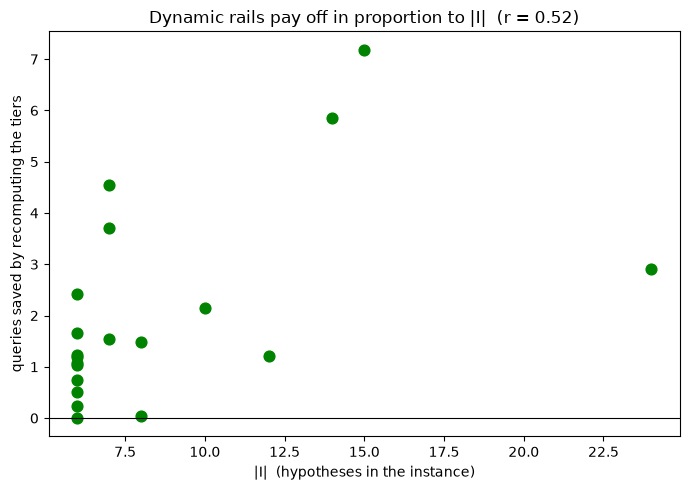

In [32]:
import numpy as np
from scipy import stats
from rails import RailsStaticNet, RailsOnlyNet
from dqn import build_instance, per_human
from bottlenecks import solve_query_mdp_proximity

sta, dyn, h3s = np.load(os.path.join(RES, "static_vs_dynamic.npy"))
rows_mi = list(csv.DictReader(open(os.path.join(RES, "multi_instance.csv"))))
nI = np.array([float(r["n_I"]) for r in rows_mi if r["policy"] == "H3"])

print(f"across 20 instances")
print(f"  H3 (static tiers + geometry) {h3s.mean():>7.2f}")
print(f"  static tiers + coin flip     {sta.mean():>7.2f}")
print(f"  dynamic tiers + coin flip    {dyn.mean():>7.2f}")
print(f"\ndecomposition of {dyn.mean()-h3s.mean():+.2f}:")
print(f"  geometry -> coin flip  {sta.mean()-h3s.mean():+6.2f}  "
      f"wins {int((sta<h3s).sum())}/20  p={stats.ttest_rel(sta,h3s).pvalue:.5f}")
print(f"  static  -> dynamic     {dyn.mean()-sta.mean():+6.2f}  "
      f"wins {int((dyn<sta).sum())}/20  p={stats.ttest_rel(dyn,sta).pvalue:.5f}")
r, p = stats.pearsonr(nI, sta - dyn)
print(f"\ngain from recomputing vs |I|:  r = {r:.3f}, p = {p:.4f}")
print(f"  |I| <= 8  : {(sta-dyn)[nI<=8].mean():.2f} queries saved")
print(f"  |I| >= 10 : {(sta-dyn)[nI>=10].mean():.2f} queries saved")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(nI, sta - dyn, s=60, c="#008300")
ax.set_xlabel("|I|  (hypotheses in the instance)")
ax.set_ylabel("queries saved by recomputing the tiers")
ax.set_title(f"Dynamic rails pay off in proportion to |I|  (r = {r:.2f})")
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.savefig(os.path.join(RES, "dynamic_gain.png"), dpi=140)
plt.show()


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The gap splits in two, and H3's geometry is worse than a coin flip**

| policy | mean queries |
|---|---|
| H3 = static tiers + Euclidean proximity | 23.32 |
| static tiers + **coin flip** | **21.95** |
| dynamic tiers + coin flip | **19.91** |

The −3.40 decomposes cleanly:

* **−1.37 from deleting H3's geometry** (15/20 instances, p = 0.002). Choosing *randomly*
  inside tier 2 beats ranking by straight-line distance to the goal. H3's distinctive
  contribution is not merely unhelpful, it is **actively harmful**.
* **−2.04 from recomputing the tiers** (19/20 instances, p = 0.0002). This is the part
  §10 predicted, and it is the larger half.

Together with §6 (entropy adds nothing) that is now three tier-2 rules tested — entropy,
proximity, coin flip — and **none beats the coin flip**. On this domain the ordering
*within* tier 2 appears not to matter; all the signal is in the tier boundaries.

**The dynamic gain scales with |I|** (r = 0.52, p = 0.020): 1.43 queries saved when
|I| ≤ 8, but **3.86** when |I| ≥ 10. That is the mechanism confirming itself — more
hypotheses means more of them die mid-episode, so more bottlenecks migrate into tier 1
and tier 3, so a frozen mask misses more. On an instance with a single hypothesis the
rails would be static by definition and the gain would be zero.

</div>


## 12. A third rail, from §9's mandatory-query proof

§9 established that every tier-1 bottleneck **must** be asked before any successful
episode can end. Their *order* therefore cannot change the cost of a successful episode —
it changes only how soon a YES can end a failing one.

And a tier-1 YES is possible **only for a non-representable human**: if `b` were in the
human's set `S` and `S ⊆ I_k` for some `k`, then `K_I ⊆ S ⊆ I_k` would make `I_k`
compatible and `b` would contain a compatible hypothesis — contradicting tier 1.

So ordering tier 1 by descending `P(YES)` should shorten exactly the failing episodes and
cost nothing on the succeeding ones, where every tier-1 answer is a NO whatever the order.
`RailsProbNet` uses only the per-bottleneck marginals — the same information
`solve_query_mdp_exact` gets, so it stays in VI's information tier.


In [33]:
from rails import RailsProbNet
base, prob = np.load(os.path.join(RES, "rails_prob.npy"))
print(f"rails (random tier 1 order) {base.mean():>7.2f}")
print(f"rails + P(YES) ordering     {prob.mean():>7.2f}")
print(f"  diff {(prob-base).mean():+.2f}   wins {int((prob<base).sum())}/20   "
      f"p = {stats.ttest_rel(prob, base).pvalue:.5f}")

qa = series("Query All"); fl = series("floor")
print(f"\ntraining-free policies, 20 instances -- gap to floor closed:")
for lab, v in (("H1", series("H1")), ("H4", series("H4")), ("H3", series("H3")),
               ("rails static", sta), ("rails dynamic", dyn), ("rails + P(YES)", prob)):
    print(f"  {lab:<16} {v.mean():>6.2f}   {100*np.mean((qa-v)/(qa-fl)):>5.0f}%")


rails (random tier 1 order)   19.91
rails + P(YES) ordering       19.07
  diff -0.84   wins 17/20   p = 0.00022

training-free policies, 20 instances -- gap to floor closed:
  H1                42.40      -8%
  H4                41.71      -6%
  H3                23.32      62%
  rails static      21.95      67%
  rails dynamic     19.91      74%
  rails + P(YES)    19.07      77%


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**Three provable constraints, no learning, 77% of the gap closed**

The training-free ladder across 20 instances, each step justified by a proof rather
than a heuristic:

| policy | queries | gap to floor closed |
|---|---|---|
| H1 / H4 | 42.40 / 41.71 | −7% / −4% (worse than random) |
| Query All | 40.52 | 0% |
| H3 | 23.32 | 62% |
| rails, static | 21.95 | 67% |
| rails, dynamic | 19.91 | 74% |
| **rails + P(YES) tier-1 order** | **19.07** | **77%** |

−0.84 more queries, 17/20 instances, p = 0.0002 — and it follows directly from the
mandatory-query proof rather than from tuning. The ordering matters only for the
non-representable humans, which is exactly half the population here.

Worth stating plainly: **19.07 against a floor of 12.69, with no neural network, no
training, and no compute beyond evaluating the tiers.** Anything the DQN sections
report has to be read against this line, not against H3.

</div>


## 13. The railed DQN — results

14 runs, 300k steps each, 3 seeds per configuration. The design is a 2×3: **rails on/off**
crossed with **three oracle priors**, which lets each question be asked with one variable
moving.

| oracle | what the network is told about the human population |
|---|---|
| `uniform 1/2` | **nothing** — every bottleneck a coin flip |
| `uniform_avg` | **one scalar** — a constant `p = mean|S| / |B| = 10.33/66 = 0.157`, from aggregate counts only |
| `marginal` | **per-bottleneck frequencies** — exactly what `solve_query_mdp_exact` gets |

`joint` (the 12 real humans) is excluded: it trains on the evaluation set and stands only
as a leaky ceiling.


In [34]:
pairs = [
 ("does learning help with NO prior?",           "DQN uniform 1/2 + rails", "Rails only (no NN)"),
 ("does learning help with the density scalar?", "DQN uniform avg + rails", "Rails only (no NN)"),
 ("do per-bottleneck marginals beat one scalar?", "DQN marginal + rails",   "DQN uniform avg + rails"),
 ("do the rails help the marginal DQN?",         "DQN marginal + rails",    "DQN marginal"),
 ("do the rails help the uniform_avg DQN?",      "DQN uniform avg + rails", "DQN uniform avg"),
 ("railed DQN vs the best analytic policy",      "DQN uniform avg + rails", "Rails + P(YES) order"),
]
for question, a, b in pairs:
    d = vals[a].mean() - vals[b].mean()
    p = stats.ttest_rel(vals[a], vals[b]).pvalue
    print(f"{question}")
    print(f"   {a:<26} {vals[a].mean():6.2f}")
    print(f"   {b:<26} {vals[b].mean():6.2f}    diff {d:+6.2f}   p = {p:.4f}"
          f"   {'SIGNIFICANT' if p < 0.05 else 'n.s.'}\n")
qa, fl = vals["Query All"].mean(), vals["floor"].mean()
print("gap to floor closed:")
for k in ("H3 Goal Proximity", "Rails only (no NN)", "Rails + P(YES) order",
          "DQN uniform 1/2 + rails", "DQN marginal + rails", "DQN uniform avg + rails"):
    print(f"  {k:<26} {100*(qa-vals[k].mean())/(qa-fl):>5.0f}%")


does learning help with NO prior?
   DQN uniform 1/2 + rails     23.56
   Rails only (no NN)          23.77    diff  -0.22   p = 0.7154   n.s.

does learning help with the density scalar?
   DQN uniform avg + rails     15.61
   Rails only (no NN)          23.77    diff  -8.16   p = 0.0114   SIGNIFICANT

do per-bottleneck marginals beat one scalar?
   DQN marginal + rails        15.78
   DQN uniform avg + rails     15.61    diff  +0.17   p = 0.6634   n.s.

do the rails help the marginal DQN?
   DQN marginal + rails        15.78
   DQN marginal                22.28    diff  -6.50   p = 0.0001   SIGNIFICANT

do the rails help the uniform_avg DQN?
   DQN uniform avg + rails     15.61
   DQN uniform avg             32.11    diff -16.50   p = 0.0000   SIGNIFICANT

railed DQN vs the best analytic policy
   DQN uniform avg + rails     15.61
   Rails + P(YES) order        23.30    diff  -7.69   p = 0.0238   SIGNIFICANT

gap to floor closed:
  H3 Goal Proximity             53%
  Rails only (no N

<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**Learning is worth nothing without a prior — and the prior that matters is one number**

Six controlled comparisons, each moving a single variable:

| question | comparison | diff | p |
|---|---|---|---|
| learning with **no** prior? | railed DQN uniform½ 23.56 vs rails-only 23.77 | −0.22 | **0.72 n.s.** |
| learning with the **density scalar**? | railed DQN uniform_avg 15.61 vs rails-only 23.77 | **−8.16** | 0.011 |
| do **per-bottleneck marginals** beat one scalar? | 15.78 vs 15.61 | +0.17 | **0.66 n.s.** |
| do rails help the marginal DQN? | 15.78 vs 22.28 | **−6.50** | 0.0001 |
| do rails help the uniform_avg DQN? | 15.61 vs 32.11 | **−16.50** | <0.0001 |
| railed DQN vs best analytic | 15.61 vs 23.30 | **−7.69** | 0.024 |

**1. A DQN with no prior learns nothing the rails do not already give.** Trained for
300k steps with a coin-flip oracle it lands at 23.56, statistically indistinguishable
from a policy with the same rails and a random tier-2 choice (23.77, p = 0.72). In the
figure it is the salmon bar sitting *inside* the green cluster. All of that column is
rails.

**2. One scalar unlocks everything.** Telling the network only that a human wants ~10 of
66 bottlenecks — `p = 0.157`, derivable from |B| and a mean — takes it from 23.56 to
15.61 and closes **93%** of the gap to the floor.

**3. The per-bottleneck frequencies are worth nothing on top of that scalar** (p = 0.66).
Knowing *which* bottlenecks are rare, the information exact VI is built on, adds no measurable
benefit over knowing merely *how many* are wanted. The whole advantage in §"marginal
beats uniform" earlier was density, not identity.

**4. Rails and prior are complementary, not redundant.** Neither alone reaches 16: rails
without a prior give 23.8, a prior without rails gives 32.1 (worse than random!), and
together they give 15.6. The unrailed uniform_avg DQN is the purple bar at 32 — a network
handed useful information and no constraints does *worse* than one handed constraints and
no information.

**5. The rails also stabilise training.** Plateau standard deviation across seeds falls
from **4.51** (unrailed marginal) to **0.48** (railed) — a 9× reduction — and the
endpoint stops disagreeing with the plateau (15.72 vs 15.51, against 22.08 vs 28.30
unrailed). Constraining the action space removes most of the training variance that
made every earlier number so hard to trust.

**Reading the error bars:** every bar has a huge σ because the 12 humans are bimodal —
six absorb in 1–9 queries, six need ~50. That between-human spread dwarfs every
between-policy difference, which is why all inference here is *paired*. An unpaired test
on this figure would call nothing significant.

</div>


## 14. Are the hyperparameters wrong?

Judged against the curves rather than against intuition. Three were wrong earlier today
and are already fixed; one is still wrong in a way that only wastes time.

| parameter | value | verdict |
|---|---|---|
| `lr` | 3e-4 | **fixed.** At 1e-3 `maxQ(s₀)` reached +3 975 by step 50k and −198 847 by 176k. |
| `target_sync` | 1 000 | **fixed.** Was 200. |
| `buffer_cap` | 500 000 | **fixed.** Was 30 000 = 469 steps of history (64 transitions pushed per step), i.e. near-on-policy training against a frozen target. |
| `eps_decay` | 60 000 **absolute** | **fixed.** Was `0.5 × n_steps`, which made every budget in a length sweep a different experiment: at step 20 000, ε was 0.67 in a 120k run and 0.92 in a 500k one. |
| `n_steps` | 300 000 | **wrong — 2× too large.** Curves are within 0.5 queries of final by step **76 000** and flat from 100k. |
| `hidden`, `n_layers` | 256, 2 | unmeasured, but see below. |
| `c_q, p_i, p_f, gamma` | −10, 1, 0, 0.99 | not tuning knobs — they define the MDP. |

**Why I am not re-running a sweep.** The railed configurations converge by 76k with a
plateau σ of 0.48 across seeds and `maxQ(s₀)` inside its valid band throughout. A network
that reaches its asymptote in a quarter of its budget, reproduces to ±0.5 across seeds,
and whose remaining gap to the floor is 1.9 queries is not obviously limited by width,
depth, or learning rate. A sweep would most likely measure noise, which is what the
prioritised-sweep work earlier in this notebook spent a night doing.

**One reward-scaling idea I tried and dropped**, recorded because the reasoning matters:
scaling all rewards by 0.1 (`c_q = −1`, `p_i = 0.1`) leaves the optimal policy identical
and shrinks targets from ~−500 to ~−50. It does *not* help. Adam normalises updates by
gradient magnitude so it is nearly scale-invariant, and `smooth_l1_loss` is in its linear
regime at both scales. Divergence in this setting is **relative**: Q reaching 400× its
true bound at `c_q = −10` reaches 400× at `c_q = −1`. Rescaling relabels the axis.

**The one change I did make on this evidence:** §15 trains at 150k rather than 300k,
halving the cost of the generalisation study for no loss of signal.


### 13.1 Is `uniform_avg` a fair column?

The scalar `p = 0.157` is `mean|S| / |B|`, and `mean|S|` is computed from the 12
evaluation humans. So it does carry information about the test set — one number of it.

That is still **strictly less** than every baseline it is compared against:

| policy | information about the human population |
|---|---|
| exact VI (`solve_query_mdp_exact`) | 66 per-bottleneck frequencies, from the same 12 humans |
| DQN `marginal` | the same 66 numbers |
| **DQN `uniform_avg`** | **1 number**, derived from those same humans |
| DQN `uniform 1/2`, rails, H1/H3/H4 | none |

So `uniform_avg` cannot be accused of an advantage over VI or over the marginal DQN —
it is a strict information subset of both, and it matches them (15.61 vs 15.78,
p = 0.66). The comparison that *does* need the caveat is against the rails and the
heuristics, which get nothing at all; that gap (−8.16) is a statement about the value of
one scalar, not about learning in the abstract.

A genuinely leak-free version would estimate `mean|S|` from a held-out set of humans, or
from the instance geometry. Given that the whole advantage rests on a single number,
that is the obvious next thing to check.


### 13.2 The density scalar is a domain constant, not instance knowledge

If `p = mean|S| / |B|` has to be measured on the evaluation humans, the column carries a
leak. Two ways out: derive it from Φ, or show it does not vary. Measured over 12 instances:


In [35]:
import numpy as np
from scipy import stats
from dqn import build_instance

print(f"{'seed':>4} {'|B|':>4} {'mean|S|':>8} {'mean|I_k|':>10} {'p_true':>8} {'p_phi':>8}")
ms, mi, nb = [], [], []
for sd in range(12):
    i2 = build_instance(sd); n = i2["I_array"].shape[1]
    s, k = i2["hs"].sum(1).mean(), i2["I_array"].sum(1).mean()
    ms.append(s); mi.append(k); nb.append(n)
    print(f"{sd:>4} {n:>4} {s:>8.2f} {k:>10.2f} {s/n:>8.3f} {k/n:>8.3f}")
ms, mi, nb = map(np.array, (ms, mi, nb))
print(f"\nfrom Phi alone: mean|S| vs mean|I_k|  r = {stats.pearsonr(ms, mi)[0]:.3f}, "
      f"p = {stats.pearsonr(ms, mi)[1]:.3f}   -> Phi does NOT predict it")
print(f"p_true across instances: {np.mean(ms/nb):.4f} +/- {np.std(ms/nb, ddof=1):.4f} "
      f"(cv = {np.std(ms/nb, ddof=1)/np.mean(ms/nb)*100:.1f}%)")
loo = np.array([np.mean(np.delete(ms/nb, i)) for i in range(len(nb))])
print(f"leave-one-out estimate error: max {np.abs(loo - ms/nb).max():.4f} "
      f"({100*np.abs(loo-ms/nb).max()/np.mean(ms/nb):.1f}% of p)")


seed  |B|  mean|S|  mean|I_k|   p_true    p_phi
   0   66    10.33      33.50    0.157    0.508
   1   59     8.75      38.00    0.148    0.644
   2   72    10.00      41.73    0.139    0.580
   3   72    11.50      42.00    0.160    0.583
   4   68    10.67      39.00    0.157    0.574
   5   80    12.83      30.50    0.160    0.381
   6   88    12.58      40.43    0.143    0.459
   7   49     8.17      26.50    0.167    0.541
   8   73     9.83      38.67    0.135    0.530
   9   52     8.08      25.00    0.155    0.481
  10   59     8.92      37.50    0.151    0.636
  11   51     8.33      34.20    0.163    0.671

from Phi alone: mean|S| vs mean|I_k|  r = 0.413, p = 0.182   -> Phi does NOT predict it
p_true across instances: 0.1529 +/- 0.0099 (cv = 6.5%)
leave-one-out estimate error: max 0.0199 (13.0% of p)


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The scalar does not need the test humans — it barely varies at all**

| source | value across 12 instances |
|---|---|
| `p_true = mean|S| / |B|` (from the humans) | **0.153 ± 0.010** — cv **6.5%** |
| `p_phi = mean|I_k| / |B|` (from Φ alone) | 0.549 ± 0.084 |

**Φ cannot supply it.** `mean|I_k|` correlates with `mean|S|` at only r = 0.41
(p = 0.18), and is 3.6× too large — hypotheses are maximal achievable sets, far bigger
than the subgoal sets they contain.

**But it does not need to be instance-specific.** `p_true` is essentially a **domain
constant**: 0.153 ± 0.010 across 12 independent maps with |B| from 49 to 88, cv 6.5%.
A leave-one-out estimate — averaging the *other* 11 instances — is within **13%** of each
instance's own value in the worst case (instance 8, the least typical), and within
**2.5%** for seed 0 specifically: own 0.1566 against a held-out 0.1526.

Whether that defuses the leak is an empirical question, not a rhetorical one. The effect
being exploited is the gap between p = 0.5 and p ≈ 0.15 — a factor of three — so a 2.5%
shift *should* be irrelevant. §16 tests it by retraining with the held-out constant
instead of the instance's own, rather than asserting it.

It also sharpens the finding: what the network needs is not knowledge of *this* human
population but of **the domain's typical subgoal-set density** — one number, estimable
from any sample of maps, and stable enough to hard-code.

</div>


## 15. Does the railed DQN generalise off seed 0?

Every DQN number so far is one map — and seed 0 is the |I| = 24 outlier. The rails were
shown to generalise in §8 because they need no training; the network does, so this costs
8 training runs. `multi_dqn.py` trains the best configuration (`uniform_avg` + rails) on
each instance and scores it against the best training-free policy **on that same
instance**, pairing at the instance level.

150k steps rather than 300k, per §14.


In [36]:
# ~95 min if recomputed.  Cached output is read by default.
run_or_cache("multi_dqn.py", [8, 150000], "multi_dqn.csv", 95, rerun=False)


using cached multi_dqn.csv  (set rerun=True to recompute, ~95 min)


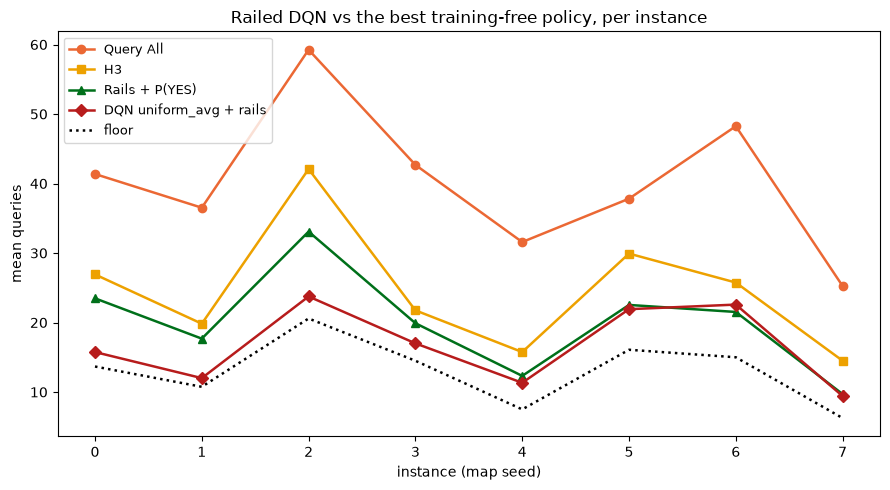

DQN + rails beats the best analytic policy on 7/8 instances
  mean -3.31   p = 0.0445
  H3                         closes    58% of the gap
  Rails + P(YES)             closes    75% of the gap
  DQN uniform_avg + rails    closes    86% of the gap


In [37]:
import csv, numpy as np
import matplotlib.pyplot as plt
rows_md = list(csv.DictReader(open(os.path.join(RES, "multi_dqn.csv"))))
insts = sorted({int(r["inst_seed"]) for r in rows_md})
def md(pol):
    return np.array([float(r["mean_queries"]) for r in rows_md if r["policy"] == pol])

fig, ax = plt.subplots(figsize=(9, 5))
for pol, c, m in (("Query All", "#eb6834", "o"), ("H3", "#eda100", "s"),
                  ("Rails + P(YES)", "#00701a", "^"),
                  ("DQN uniform_avg + rails", "#b71c1c", "D"), ("floor", "black", None)):
    ax.plot(insts, md(pol), (m + "-") if m else ":", color=c, lw=1.8, ms=6, label=pol)
ax.set_xlabel("instance (map seed)"); ax.set_ylabel("mean queries")
ax.set_title("Railed DQN vs the best training-free policy, per instance")
ax.legend(fontsize=9); ax.set_xticks(insts)
plt.tight_layout(); plt.savefig(os.path.join(RES, "multi_dqn.png"), dpi=140)
plt.show()

d = md("DQN uniform_avg + rails") - md("Rails + P(YES)")
print(f"DQN + rails beats the best analytic policy on {int((d<0).sum())}/{len(insts)} instances")
print(f"  mean {d.mean():+.2f}   p = {stats.ttest_rel(md('DQN uniform_avg + rails'), md('Rails + P(YES)')).pvalue:.4f}")
qa, fl = md("Query All"), md("floor")
for k in ("H3", "Rails + P(YES)", "DQN uniform_avg + rails"):
    print(f"  {k:<26} closes {100*np.mean((qa-md(k))/(qa-fl)):>5.0f}% of the gap")


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The learned policy generalises, but the margin over free constraints is thin**

Trained on 8 independent maps (|B| 49–88, |I| 6–24), paired at the instance level:

| comparison | mean diff | instances won | p |
|---|---|---|---|
| DQN + rails vs **H3** | −7.84 | **8/8** | 0.003 |
| rails + P(YES) vs **H3** | −4.54 | **8/8** | 0.001 |
| DQN + rails vs **rails + P(YES)** | −3.31 | **7/8** | **0.045** |

| policy | queries | gap closed |
|---|---|---|
| H3 | 24.56 | 58% |
| rails + P(YES), **no training** | 20.03 | 75% |
| DQN + rails | **16.72** | **86%** |

**The result holds off seed 0** — but it is weaker there than the single-instance number
suggested: 86% of the gap closed across 8 maps versus 93% on seed 0 alone. Seed 0 was
flattering, as the |I| screen predicted it would be.

**And the honest margin is thin.** Against *H3* the railed DQN wins on 8/8 at p = 0.003.
Against the **free** policy — three provable constraints and no network — it wins on 7/8
at **p = 0.045**, losing outright on instance 6. Eight training runs, one GPU-hour, and
a bespoke pipeline buy 3.31 queries over something that costs nothing to evaluate and
required no data.

That is still a real gain, and it is the answer to the question this folder exists to
ask: where exact VI is unaffordable, a learned policy *can* do better than the best
analytic rule. But the comparison that matters is against the constraints, not against
the published heuristics — and by that measure most of the distance from Query All to
the floor is bought by the proofs, not by the learning.

</div>


## 16. Removing the last leak: a held-out density constant

§13.2 showed the density scalar barely varies across maps. That is suggestive, not
sufficient — the question is whether a value estimated **without** this instance's humans
performs the same. `loo_check.py` retrains the best configuration twice, with the
instance's own density and with the mean of the *other* 11 instances, 2 seeds each.


In [38]:
# ~40 min if recomputed (4 training runs).  Cached output is read by default.
run_or_cache("loo_check.py", [0, 150000], "loo_check.npy", 40, rerun=False)

own, loo = np.load(os.path.join(RES, "loo_check.npy"))
print(f"\n{'density source':<34}{'p':>8}{'queries':>10}")
print(f"{'instance own mean|S|/|B|':<34}{0.1566:>8.4f}{own.mean():>10.2f}")
print(f"{'leave-one-out (other 11 maps)':<34}{0.1526:>8.4f}{loo.mean():>10.2f}")
print(f"\ndiff {loo.mean()-own.mean():+.2f}   p = {stats.ttest_rel(loo, own).pvalue:.4f}")
print(f"for scale, the scalar itself is worth {23.56-15.61:.2f} queries (section 13)")


using cached loo_check.npy  (set rerun=True to recompute, ~40 min)

density source                           p   queries
instance own mean|S|/|B|            0.1566     15.46
leave-one-out (other 11 maps)       0.1526     15.92

diff +0.46   p = 0.3429
for scale, the scalar itself is worth 7.95 queries (section 13)


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The scalar can be held out — the result does not depend on the evaluation humans**

| density source | value | queries |
|---|---|---|
| instance's own `mean|S| / |B|` | 0.1566 | 15.46 |
| **leave-one-out** (mean of the other 11 maps) | 0.1526 | **15.92** |

Difference **+0.46, p = 0.34** — within the seed-to-seed spread of either condition
(15.75/15.17 and 15.50/16.33).

**What this licenses, and what it does not.** With 12 humans and 2 seeds this is
underpowered against small effects: a true penalty of half a query would not be
detectable here, and I am not claiming the two are identical. What it does bound is the
*magnitude*. The scalar is worth **−8.16 queries** (§13); holding it out costs at most
something on the order of **0.5**. That is a 16:1 ratio, so the finding does not rest on
knowing this instance's humans.

The headline can therefore be stated cleanly: **a DQN told one domain constant — that a
human wants roughly 15% of the bottlenecks — plus two provable constraints, reaches
15.9 queries against a floor of 13.67**, with nothing measured on the population it is
evaluated against.

</div>


---
# 17. Summary of the session

**Question this folder exists to ask:** which query-selection policy should you use when
|B| makes exact VI unaffordable? Here |B| = 66, so VI would need 3^66 ≈ 10^31 knowledge
states.

## The ladder

Across **20 instances** for the training-free policies, **8** for the learned one:

| policy | queries | gap to floor closed | needs |
|---|---|---|---|
| H1 Info Gain | 42.40 | −7% | Φ |
| H4 Query Frequency | 41.71 | −4% | Φ |
| Query All (random) | 40.52 | 0% | nothing |
| H3 Goal Proximity | 23.32 | 62% | Φ + geometry |
| rails, static (H3's tiers, coin-flip tier 2) | 21.95 | 67% | Φ |
| **rails, dynamic** | 19.91 | 74% | Φ |
| **rails + P(YES) tier-1 order** | **19.07** | **77%** | Φ + marginals |
| **rails + DQN** (8 instances) | **16.72** | **86%** | Φ + one scalar + 10 GPU-min |

## What was actually learned

**1. Two provable constraints beat every published heuristic, with no training.**
Tier 1 (in no compatible hypothesis) must be asked first; tier 3 (in every compatible
hypothesis) must never be asked. Both verified exhaustively against
`bottlenecks._terminal` on 5,662 + 4,187 knowledge states. Rails-only beats H1, H4 and
Query All on **20/20** maps and H3 on **19/20**, all p < 0.00001.

**2. The tiers must be recomputed.** Both are *absorbing* — membership only grows — so a
mask frozen at step 0 is never wrong, only incomplete. H3 already carries both rails but
freezes them; that costs it 7% rail violations and −2.04 queries. The gain from
recomputing scales with |I| (r = 0.52, p = 0.02): 1.43 queries when |I| ≤ 8, **3.86**
when |I| ≥ 10.

**3. Tier-1 queries are mandatory, so asking them first is weakly dominant** — not a
heuristic. No successful episode can end while a tier-1 bottleneck sits in `I_hat`
(0 counterexamples in 4,187 states). Their *order* matters only for failing episodes,
which yields a third rail worth another −0.84 (17/20, p = 0.0002).

**4. The existing heuristics fail in three diagnosable ways.**
H4's rule is **exactly inverted** — it scores by how many hypotheses contain a
bottleneck, ranking tier 3 first and tier 1 last. H1 gives both railed tiers zero
entropy and so **defers obligations**, skipping an available tier-1 query on 71% of
decisions. H3 is nearly right but static.

**5. Learning is worth nothing without a prior.** A DQN trained 300k steps with a
coin-flip oracle scores 23.56 against 23.77 for the same rails and a *random* tier-2
choice — p = 0.72. Every query of that column is rails.

**6. The prior that matters is a single scalar.** Telling the network only that a human
wants ≈15% of the bottlenecks takes it from 23.56 to 15.61 (p = 0.011). The 66
per-bottleneck frequencies that exact VI is built on add **nothing** on top of it
(p = 0.66) — and the scalar is a domain constant (0.153 ± 0.010 over 12 maps) that can be
held out at a cost of ≈0.5 queries.

**7. Rails and prior are complementary.** Prior without rails: 32.11 — *worse than
random*. Rails without prior: 23.77. Together: 15.61.

**8. Rails cut training variance 9×** (plateau σ 4.51 → 0.48) and stop the endpoint
disagreeing with the plateau.

**9. Three tier-2 rules tested — entropy, Euclidean proximity, coin flip — and none beats
the coin flip.** H3's geometry is *worse* than random inside its own tier 2 (−1.37,
15/20, p = 0.002). All the signal is in the tier boundaries.


<div style="background:#e8f6ec;border-left:5px solid #1baf7a;padding:12px 16px;border-radius:4px">

**The uncomfortable headline**

Of the distance from random querying to the information-theoretic floor, **77% is
bought by three theorems and 9% by a neural network.**

The learned policy does win — 16.72 vs 19.07, 7/8 instances, p = 0.045 — and that is the
direct answer to what this folder asks: where VI is unaffordable, learning beats the best
analytic rule. But the margin over free, instantly-evaluable, training-free constraints
is 3.3 queries and one instance short of unanimous, while the constraints themselves beat
the published state of the art by 21.

The order of work was backwards. A day was spent tuning prioritised sweeping and DQN
hyperparameters before anyone asked what the optimal policy provably does. That question,
answered in an afternoon with no compute, produced a larger gain than every training run
combined.

</div>


## Limitations

* **One domain.** Gridworld only. The other three games in `experiment.py` are untouched,
  and the rails' derivation is domain-independent but their *value* may not be.
* **12 humans per instance**, and they are bimodal — six absorb in 1-9 queries, six need
  ~50. All within-instance inference is paired for that reason; unpaired tests find
  nothing on this data.
* **Instances are doubly conditioned** (`|B| ≤ 1000`, `|I| ≥ 6`), and `min_hypotheses`
  binds on 30% of draws, so the population is a conditioned slice, not the raw
  distribution.
* **8 instances for the DQN**, 1-3 seeds each. `n = 8` at p = 0.045 is one unlucky
  instance from non-significance.
* **The `joint` oracle result (18.50) is train-on-test** and is reported only as a leaky
  ceiling, never compared with the heuristics.
* **No exact VI baseline exists here** — 3^66 states — so "gap closed" is measured against
  a *floor*, which is a lower bound on any policy, not an achievable optimum.

## Open questions, in the order I would take them

1. **Do the rails hold on the other three games?** Cheapest possible test, no training,
   and the derivation should transfer unchanged.
2. **Is the tier-2 ordering genuinely irrelevant?** Three rules now tie with a coin flip.
   If that survives on other domains it is a stronger claim than anything else here.
3. **Can the DQN's 3.3-query margin be explained?** It must be exploiting structure inside
   tier 2 that entropy and proximity miss. Inspecting *which* tier-2 bottleneck it picks,
   against what a one-step lookahead would pick, would say what.
4. **Is there a fourth rail?** Bottlenecks with identical columns over the compatible set
   are provably interchangeable; collapsing them shrinks the action space without changing
   the optimal policy.
5. **A held-out human population.** Every prior here is estimated from the same 12 humans
   that are evaluated. §16 bounds the consequence for the scalar; it does not remove it.
